## Setup

In [1]:
# CELL 1 — Install packages
!pip install -q datasets transformers sentence-transformers scikit-learn xgboost torch accelerate gdown shap matplotlib seaborn bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.5 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is inc

In [2]:
# CELL 2 — Imports and random seeds
import random
import numpy as np
import torch
import warnings
import logging
import re
import json
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Fix random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Suppress warnings
warnings.filterwarnings('ignore')
logging.getLogger('transformers').setLevel(logging.ERROR)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'VRAM: {round(torch.cuda.get_device_properties(0).total_memory/1e9,1)} GB')
print('Setup complete ✅')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Setup complete ✅


In [3]:
# CELL 3 — HuggingFace Login
from kaggle_secrets import UserSecretsClient
secrets = UserSecretsClient()
hf_token = secrets.get_secret('Hallucination')
os.environ['HF_TOKEN'] = hf_token
from huggingface_hub import login
login(token=hf_token)
print('HuggingFace logged in ✅')

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HuggingFace logged in ✅


##  Phase 1 — Data Preparation

In [4]:
# CELL 4 — Preprocessing function
def preprocess_text(text):
    if not isinstance(text, str):
        return ''
    text = text.strip()
    text = ' '.join(text.split())
    text = re.sub(r'[^\w\s\?\.\,\!\-]', '', text)
    return text

print('Preprocessing function defined ✅')

Preprocessing function defined ✅


In [5]:
# CELL 5 — Load HaluEval
from datasets import load_dataset

print('Loading HaluEval...')
halueval_raw = load_dataset('pminervini/HaluEval', 'qa_samples', split='data')
df_halueval = pd.DataFrame(halueval_raw)
df_halueval['label']    = df_halueval['hallucination'].apply(lambda x: 1 if x == 'yes' else 0)
df_halueval['question'] = df_halueval['question'].apply(preprocess_text)
df_halueval['answer']   = df_halueval['answer'].apply(preprocess_text)
print(f'✅ HaluEval: {len(df_halueval)} samples | Hallucination rate: {df_halueval["label"].mean()*100:.1f}%')
print(df_halueval['label'].value_counts())

Loading HaluEval...


README.md: 0.00B [00:00, ?B/s]

qa_samples/data-00000-of-00001.parquet:   0%|          | 0.00/3.43M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

✅ HaluEval: 10000 samples | Hallucination rate: 50.1%
label
1    5010
0    4990
Name: count, dtype: int64


In [6]:
# CELL 6 — Load TruthfulQA
print('Loading TruthfulQA...')
truthfulqa_raw = load_dataset('truthful_qa', 'generation', split='validation')
tqa_rows = []
for sample in truthfulqa_raw:
    for ans in sample['correct_answers']:
        tqa_rows.append({'question': preprocess_text(sample['question']), 'answer': preprocess_text(ans), 'label': 0})
    for ans in sample['incorrect_answers']:
        tqa_rows.append({'question': preprocess_text(sample['question']), 'answer': preprocess_text(ans), 'label': 1})
df_tqa = pd.DataFrame(tqa_rows)
print(f'✅ TruthfulQA: {len(df_tqa)} samples | Hallucination rate: {df_tqa["label"].mean()*100:.1f}%')
print(df_tqa['label'].value_counts())

Loading TruthfulQA...


README.md: 0.00B [00:00, ?B/s]

generation/validation-00000-of-00001.par(…):   0%|          | 0.00/223k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/817 [00:00<?, ? examples/s]

✅ TruthfulQA: 5918 samples | Hallucination rate: 56.1%
label
1    3318
0    2600
Name: count, dtype: int64


In [7]:
# CELL 7 — Download FActScore
import gdown
os.makedirs('./factscore_labeled', exist_ok=True)
gdown.download(id='155exEdKs7R21gZF4G-x54-XN3qswBcPo', output='./factscore_labeled/data.zip', quiet=False)
import zipfile
with zipfile.ZipFile('./factscore_labeled/data.zip', 'r') as z:
    z.extractall('./factscore_data')
print('FActScore downloaded and extracted ✅')

Downloading...
From: https://drive.google.com/uc?id=155exEdKs7R21gZF4G-x54-XN3qswBcPo
To: /kaggle/working/factscore_labeled/data.zip
100%|██████████| 2.20M/2.20M [00:00<00:00, 165MB/s]

FActScore downloaded and extracted ✅


In [10]:
# CELL 8 — Load FActScore
print('Loading FActScore...')
fs_rows = []
for filepath in ['./factscore_data/data/labeled/InstructGPT.jsonl','./factscore_data/data/labeled/ChatGPT.jsonl','./factscore_data/data/labeled/PerplexityAI.jsonl']:
    with open(filepath, 'r') as f:
        for line in f:
            dp = json.loads(line)
            topic = dp['topic']
            if not dp.get('annotations'): continue
            for ann in dp['annotations']:
                human_facts = ann.get('human-atomic-facts')
                if not human_facts: continue  # ← fix here
                for fact in human_facts:
                    if fact.get('label') == 'IR': continue
                    fs_rows.append({
                        'question': preprocess_text(f'Tell me a bio of {topic}'),
                        'answer'  : preprocess_text(fact.get('text','')),
                        'label'   : 0 if fact.get('label')=='S' else 1
                    })
df_fs = pd.DataFrame(fs_rows)
print(f'✅ FActScore: {len(df_fs)} samples | Hallucination rate: {df_fs["label"].mean()*100:.1f}%')
print(df_fs['label'].value_counts())

Loading FActScore...
✅ FActScore: 14525 samples | Hallucination rate: 30.4%
label
0    10106
1     4419
Name: count, dtype: int64


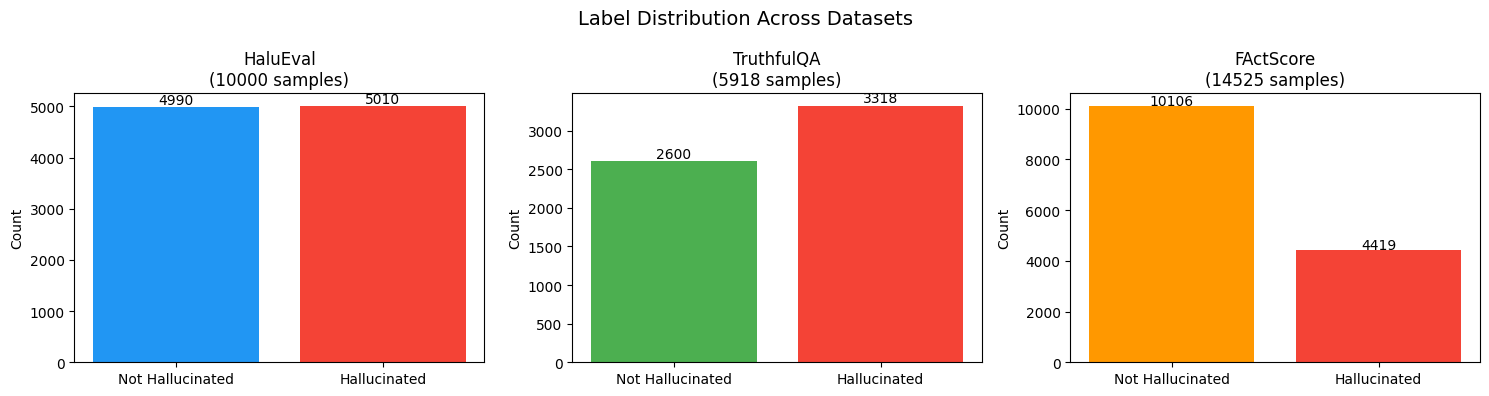


Dataset Summary:
   Dataset  Total Samples  Hallucinated  Not Hallucinated Hallucination %
  HaluEval          10000          5010              4990           50.1%
TruthfulQA           5918          3318              2600           56.1%
 FActScore          14525          4419             10106           30.4%


In [11]:
# CELL 9 — Dataset statistics and plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
datasets_info = [
    ('HaluEval', df_halueval),
    ('TruthfulQA', df_tqa),
    ('FActScore', df_fs)
]
colors = ['#2196F3', '#4CAF50', '#FF9800']
for ax, (name, df), color in zip(axes, datasets_info, colors):
    counts = df['label'].value_counts()
    ax.bar(['Not Hallucinated', 'Hallucinated'], [counts.get(0,0), counts.get(1,0)], color=[color, '#F44336'])
    ax.set_title(f'{name}\n({len(df)} samples)', fontsize=12)
    ax.set_ylabel('Count')
    for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
        ax.text(i, v + 50, str(v), ha='center', fontsize=10)
plt.suptitle('Label Distribution Across Datasets', fontsize=14)
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nDataset Summary:')
summary = pd.DataFrame({
    'Dataset'          : ['HaluEval', 'TruthfulQA', 'FActScore'],
    'Total Samples'    : [len(df_halueval), len(df_tqa), len(df_fs)],
    'Hallucinated'     : [df_halueval['label'].sum(), df_tqa['label'].sum(), df_fs['label'].sum()],
    'Not Hallucinated' : [(df_halueval['label']==0).sum(), (df_tqa['label']==0).sum(), (df_fs['label']==0).sum()],
    'Hallucination %'  : [f'{df_halueval["label"].mean()*100:.1f}%', f'{df_tqa["label"].mean()*100:.1f}%', f'{df_fs["label"].mean()*100:.1f}%']
})
print(summary.to_string(index=False))

##  Phase 2 — Feature Extraction

In [12]:
# CELL 10 — Load feature extraction models
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline

print('Loading MiniLM for semantic similarity...')
similarity_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print('Loading NLI model...')
nli_model = pipeline('text-classification', model='cross-encoder/nli-MiniLM2-L6-H768', device=0 if torch.cuda.is_available() else -1)
print('Feature models ready ✅')

Loading MiniLM for semantic similarity...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Feature models ready ✅


In [13]:
# CELL 11 — Feature functions
def get_semantic_similarity(q, a):
    e1 = similarity_model.encode(q, convert_to_tensor=True)
    e2 = similarity_model.encode(a, convert_to_tensor=True)
    return util.cos_sim(e1, e2).item()

def get_nli_score(q, a):
    result = nli_model(f'{q} [SEP] {a}', truncation=True, max_length=512)
    label  = result[0]['label'].lower()
    score  = result[0]['score']
    if 'entail' in label: return score
    elif 'contradict' in label: return -score
    return 0.0

def get_entity_overlap(q, a):
    q_words = set(re.findall(r'\b\w+\b', q.lower()))
    a_words = set(re.findall(r'\b\w+\b', a.lower()))
    if not q_words: return 0.0
    return len(q_words & a_words) / len(q_words)

def get_answer_length(a):
    return min(len(a.split()) / 100.0, 1.0)

def extract_features(question, answer):
    return [
        get_semantic_similarity(question, answer),  # F1: Semantic Similarity
        get_nli_score(question, answer),             # F2: NLI Score
        get_entity_overlap(question, answer),        # F3: Entity Overlap
        get_answer_length(answer)                    # F4: Answer Length
    ]

print('Feature functions defined ✅')

# Quick test
q = 'What is the capital of France?'
a_correct = 'The capital of France is Paris.'
a_wrong   = 'The capital of France is Berlin.'
fc = extract_features(q, a_correct)
fw = extract_features(q, a_wrong)
feature_names = ['Semantic Similarity', 'NLI Score', 'Entity Overlap', 'Answer Length']
print(f'\n{"Feature":<22} {"Correct":>10} {"Hallucinated":>14}')
print('-'*48)
for name, c, w in zip(feature_names, fc, fw):
    print(f'{name:<22} {c:>10.4f} {w:>14.4f}')

Feature functions defined ✅

Feature                   Correct   Hallucinated
------------------------------------------------
Semantic Similarity        0.8790         0.7496
NLI Score                  0.0000        -0.5049
Entity Overlap             0.8333         0.8333
Answer Length              0.0600         0.0600


In [14]:
# CELL 12 — Extract features from all datasets
print('Extracting features from HaluEval...')
X_halueval = np.array([extract_features(r['question'], r['answer']) for _, r in tqdm(df_halueval.iterrows(), total=len(df_halueval), desc='HaluEval')])
y_halueval = df_halueval['label'].values
print(f'HaluEval: {X_halueval.shape} ✅')

print('\nExtracting features from TruthfulQA...')
X_tqa = np.array([extract_features(r['question'], r['answer']) for _, r in tqdm(df_tqa.iterrows(), total=len(df_tqa), desc='TruthfulQA')])
y_tqa = df_tqa['label'].values
print(f'TruthfulQA: {X_tqa.shape} ✅')

print('\nExtracting features from FActScore...')
X_fs = np.array([extract_features(r['question'], r['answer']) for _, r in tqdm(df_fs.iterrows(), total=len(df_fs), desc='FActScore')])
y_fs = df_fs['label'].values
print(f'FActScore: {X_fs.shape} ✅')

Extracting features from HaluEval...


HaluEval:   0%|          | 0/10000 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


HaluEval: (10000, 4) ✅

Extracting features from TruthfulQA...


TruthfulQA:   0%|          | 0/5918 [00:00<?, ?it/s]

TruthfulQA: (5918, 4) ✅

Extracting features from FActScore...


FActScore:   0%|          | 0/14525 [00:00<?, ?it/s]

FActScore: (14525, 4) ✅


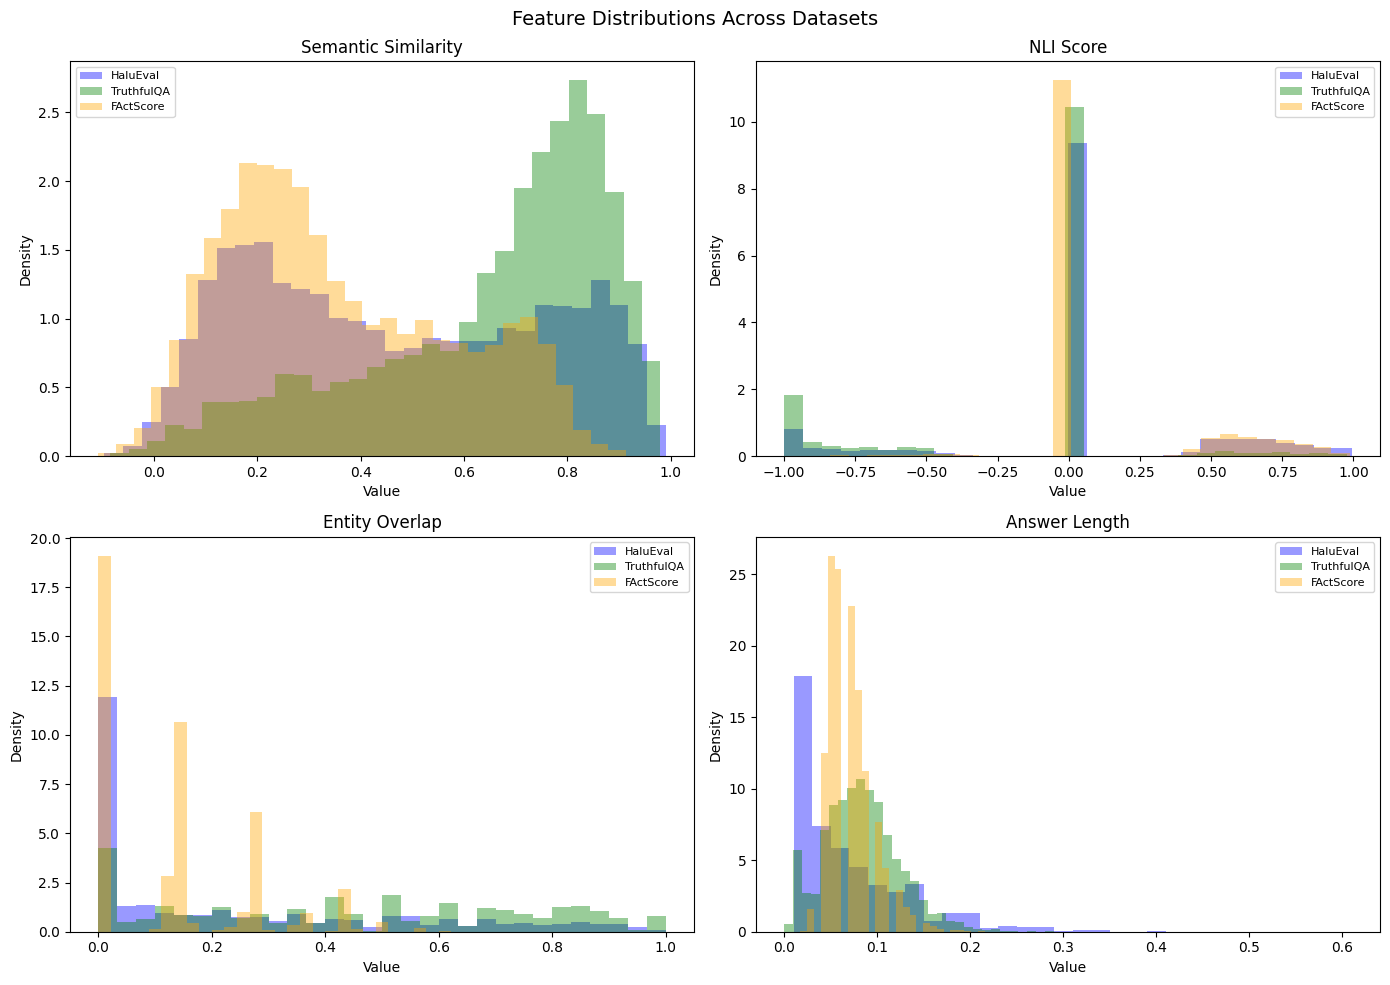

Saved feature_distributions.png ✅


In [15]:
# CELL 13 — Feature distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
feature_names = ['Semantic Similarity', 'NLI Score', 'Entity Overlap', 'Answer Length']
axes = axes.flatten()
for i, (ax, fname) in enumerate(zip(axes, feature_names)):
    for X, y, label, color in [(X_halueval, y_halueval, 'HaluEval', 'blue'), (X_tqa, y_tqa, 'TruthfulQA', 'green'), (X_fs, y_fs, 'FActScore', 'orange')]:
        ax.hist(X[:, i], bins=30, alpha=0.4, label=label, color=color, density=True)
    ax.set_title(fname)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
plt.suptitle('Feature Distributions Across Datasets', fontsize=14)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved feature_distributions.png ✅')

##  Phase 3 — Model Training & Evaluation
### Helper Functions

In [31]:
# CELL 14 — Helper imports and functions
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

class HallucinationDataset(Dataset):
    def __init__(self, questions, answers, labels, tokenizer, max_len=512):
        self.questions = questions
        self.answers   = answers
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        text = f'{self.questions[idx]} [SEP] {self.answers[idx]}'
        enc  = self.tokenizer(text, max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(), 'attention_mask': enc['attention_mask'].squeeze(), 'label': torch.tensor(self.labels[idx], dtype=torch.long)}

def evaluate_classical(clf, X_test, y_test):
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1] if hasattr(clf, 'predict_proba') else y_pred
    return {
        'accuracy' : accuracy_score(y_test, y_pred),
        'auc'      : roc_auc_score(y_test, y_prob),
        'report'   : classification_report(y_test, y_pred, target_names=['Not Hallucinated', 'Hallucinated']),
        'cm'       : confusion_matrix(y_test, y_pred),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob
    }

def evaluate_transformer(model, tokenizer, df_test, y_test):
    model.eval()
    ds = HallucinationDataset(df_test['question'].tolist(), df_test['answer'].tolist(), y_test.tolist(), tokenizer)
    dl = DataLoader(ds, batch_size=32, shuffle=False)
    all_preds, all_probs = [], []
    with torch.no_grad():
        for batch in dl:
            logits = model(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device)).logits
            probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds  = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_probs.extend(probs)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)
    return {
        'accuracy' : accuracy_score(y_test, y_pred),
        'auc'      : roc_auc_score(y_test, y_prob),
        'report'   : classification_report(y_test, y_pred, target_names=['Not Hallucinated', 'Hallucinated']),
        'cm'       : confusion_matrix(y_test, y_pred),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob
    }

def plot_confusion_matrix(cm, title, ax):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Hall.', 'Hall.'],
                yticklabels=['Not Hall.', 'Hall.'])
    ax.set_title(title)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

def train_transformer(model, tokenizer, df_train, y_train, model_name, epochs=3):
    ds = HallucinationDataset(df_train['question'].tolist(), df_train['answer'].tolist(), y_train.tolist(), tokenizer)
    dl = DataLoader(ds, batch_size=32, shuffle=True)
    optimizer = AdamW(model.parameters(), lr=2e-5)
    print(f'Training {model_name}...')
    best_loss = float('inf')
    
    for epoch in range(epochs):
        epoch_start = time.time()  # ← time
        model.train()
        total_loss = 0
        correct    = 0
        total      = 0
        
        for batch in tqdm(dl, desc=f'Epoch {epoch+1}/{epochs}'):
            optimizer.zero_grad()
            out = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['label'].to(device)
            )
            out.loss.backward()
            optimizer.step()
            total_loss += out.loss.item()
            
            # Training accuracy
            preds    = out.logits.argmax(dim=1)
            correct += (preds == batch['label'].to(device)).sum().item()
            total   += batch['label'].size(0)
        
        avg_loss  = total_loss / len(dl)
        train_acc = correct / total * 100
        epoch_time = time.time() - epoch_start  # ← time
        
        print(f'Epoch {epoch+1} | Loss: {avg_loss:.4f} | Acc: {train_acc:.2f}% | Time: {epoch_time:.1f}s')
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), f'{model_name}_best.pt')
    
    model.load_state_dict(torch.load(f'{model_name}_best.pt'))
    print(f'{model_name} training done ✅')
    return model

print('Helper functions defined ✅')

Helper functions defined ✅


In [32]:
# CELL 15 — Load all transformer models
print('Loading DistilBERT...')
distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
distilbert_model     = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2).to(device)
print('DistilBERT ready ✅')

print('Loading TinyBERT...')
tinybert_tokenizer = AutoTokenizer.from_pretrained('huawei-noah/TinyBERT_General_4L_312D')
tinybert_model     = AutoModelForSequenceClassification.from_pretrained('huawei-noah/TinyBERT_General_4L_312D', num_labels=2).to(device)
print('TinyBERT ready ✅')

print('Loading MiniLM...')
minilm_tokenizer = AutoTokenizer.from_pretrained('microsoft/MiniLM-L12-H384-uncased')
minilm_model     = AutoModelForSequenceClassification.from_pretrained('microsoft/MiniLM-L12-H384-uncased', num_labels=2).to(device)
print('MiniLM ready ✅')

Loading DistilBERT...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT ready ✅
Loading TinyBERT...


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     | 
-------------------------------------------+------------+-
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED | 
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not o

TinyBERT ready ✅
Loading MiniLM...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: microsoft/MiniLM-L12-H384-uncased
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


MiniLM ready ✅


### 📗 Code 1 — Train on HaluEval, Test on TruthfulQA + FActScore

In [33]:
from sklearn.metrics import accuracy_score, log_loss
import time

print('='*60)
print('CODE 1 — Training on HaluEval')
print('='*60)

clf1_lr  = LogisticRegression(max_iter=1000, random_state=SEED)
clf1_rf  = RandomForestClassifier(n_estimators=100, random_state=SEED)
clf1_xgb = XGBClassifier(n_estimators=100, random_state=SEED, eval_metric='logloss')

for name, clf in [('Logistic Regression', clf1_lr), ('Random Forest', clf1_rf), ('XGBoost', clf1_xgb)]:
    start     = time.time()
    clf.fit(X_halueval, y_halueval)
    elapsed   = time.time() - start
    train_acc = accuracy_score(y_halueval, clf.predict(X_halueval))
    train_loss = log_loss(y_halueval, clf.predict_proba(X_halueval))
    print(f'{name} → Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}% | Time: {elapsed:.2f}s ✅')

CODE 1 — Training on HaluEval
Logistic Regression → Loss: 0.2223 | Acc: 91.57% | Time: 0.05s ✅
Random Forest → Loss: 0.0363 | Acc: 99.99% | Time: 1.51s ✅
XGBoost → Loss: 0.0973 | Acc: 96.69% | Time: 0.10s ✅


In [34]:
# CELL 17 — Code 1: Train transformer models on HaluEval
distilbert_model = train_transformer(distilbert_model, distilbert_tokenizer, df_halueval, y_halueval, 'distilbert_c1')
tinybert_model   = train_transformer(tinybert_model,   tinybert_tokenizer,   df_halueval, y_halueval, 'tinybert_c1')
minilm_model     = train_transformer(minilm_model,     minilm_tokenizer,     df_halueval, y_halueval, 'minilm_c1')

Training distilbert_c1...


Epoch 1/3:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 1 | Loss: 0.1481 | Acc: 95.14% | Time: 445.7s


Epoch 2/3:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 2 | Loss: 0.0868 | Acc: 97.83% | Time: 444.8s


...

Epoch 1 | Loss: 0.1873 | Acc: 94.24% | Time: 336.3s


Epoch 2/3:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 2 | Loss: 0.1092 | Acc: 97.44% | Time: 336.5s


Epoch 3/3:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 3 | Loss: 0.0978 | Acc: 97.51% | Time: 336.2s
minilm_c1 training done ✅


In [35]:
# CELL 18 — Code 1: Evaluate on TruthfulQA + FActScore
code1_results = {}
test_sets = {'TruthfulQA': (X_tqa, y_tqa, df_tqa), 'FActScore': (X_fs, y_fs, df_fs)}

for test_name, (X_test, y_test, df_test) in test_sets.items():
    print(f'\nTesting on {test_name}:')
    code1_results[test_name] = {}
    for name, clf in [('Logistic Regression', clf1_lr), ('Random Forest', clf1_rf), ('XGBoost', clf1_xgb)]:
        res = evaluate_classical(clf, X_test, y_test)
        code1_results[test_name][name] = res
        print(f'  {name}: Acc={res["accuracy"]*100:.2f}% | AUC={res["auc"]:.4f}')
    for name, model, tok in [('DistilBERT', distilbert_model, distilbert_tokenizer), ('TinyBERT', tinybert_model, tinybert_tokenizer), ('MiniLM', minilm_model, minilm_tokenizer)]:
        res = evaluate_transformer(model, tok, df_test, y_test)
        code1_results[test_name][name] = res
        print(f'  {name}: Acc={res["accuracy"]*100:.2f}% | AUC={res["auc"]:.4f}')


Testing on TruthfulQA:
  Logistic Regression: Acc=55.47% | AUC=0.5233
  Random Forest: Acc=54.90% | AUC=0.5244
  XGBoost: Acc=54.87% | AUC=0.5057
  DistilBERT: Acc=44.73% | AUC=0.5237
  TinyBERT: Acc=44.14% | AUC=0.5463
  MiniLM: Acc=52.53% | AUC=0.5673

Testing on FActScore:
  Logistic Regression: Acc=54.05% | AUC=0.4949
  Random Forest: Acc=42.71% | AUC=0.5074
  XGBoost: Acc=44.41% | AUC=0.5031
  DistilBERT: Acc=42.90% | AUC=0.4209
  TinyBERT: Acc=30.56% | AUC=0.4848
  MiniLM: Acc=30.53% | AUC=0.5414


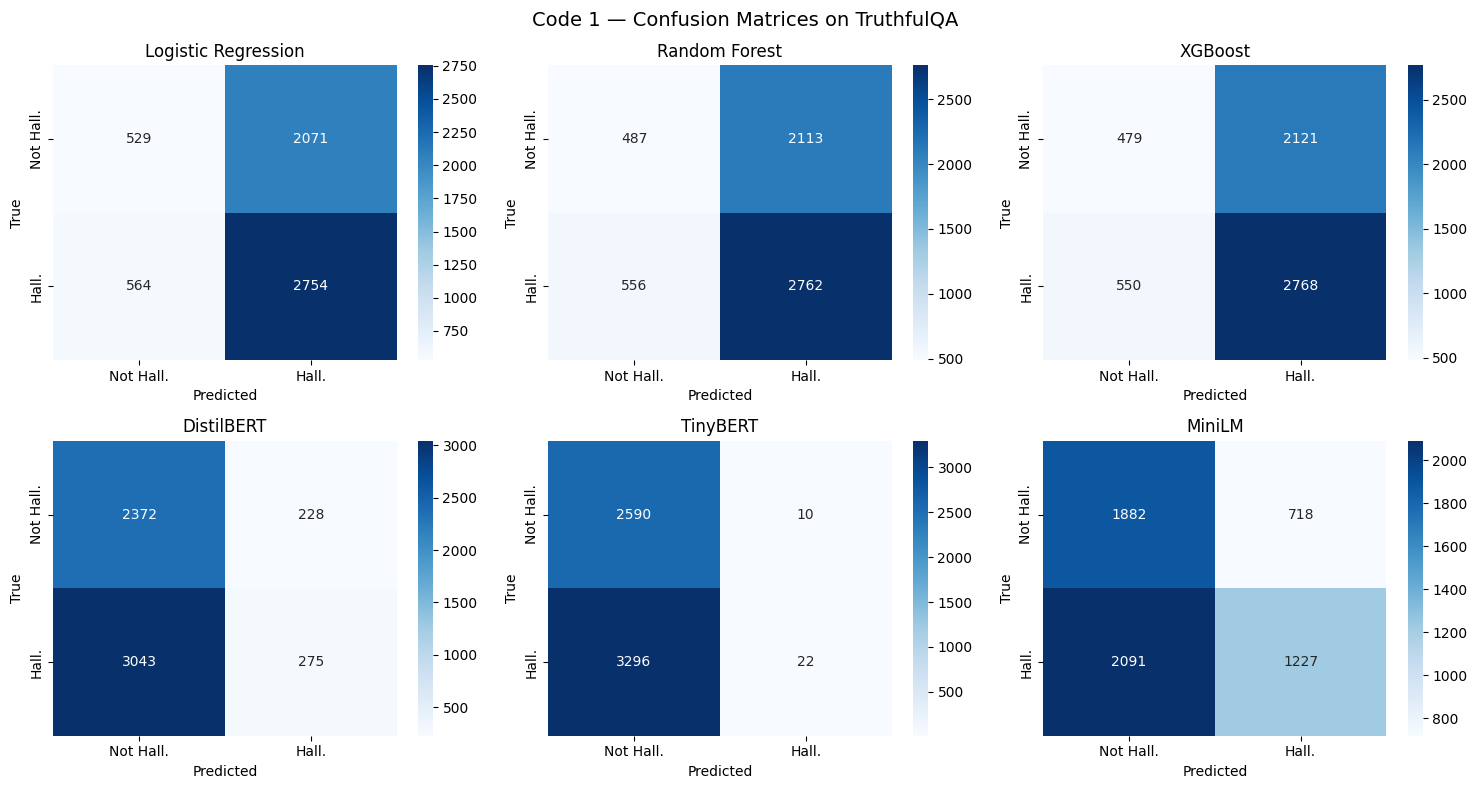

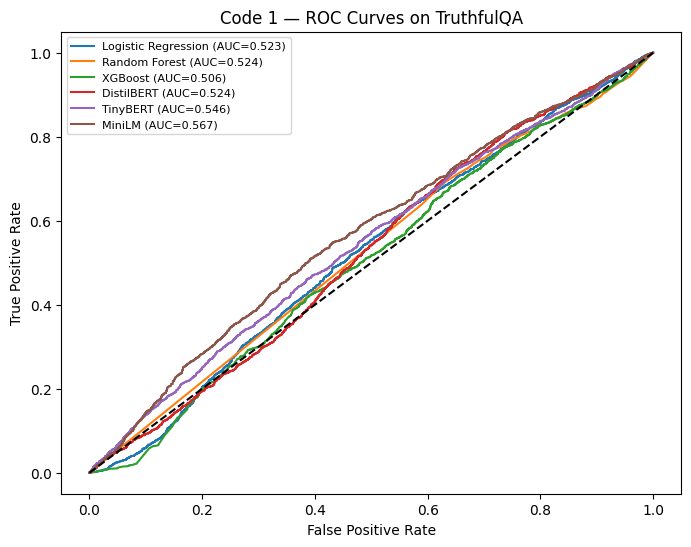

Saved Code 1 figures for TruthfulQA ✅


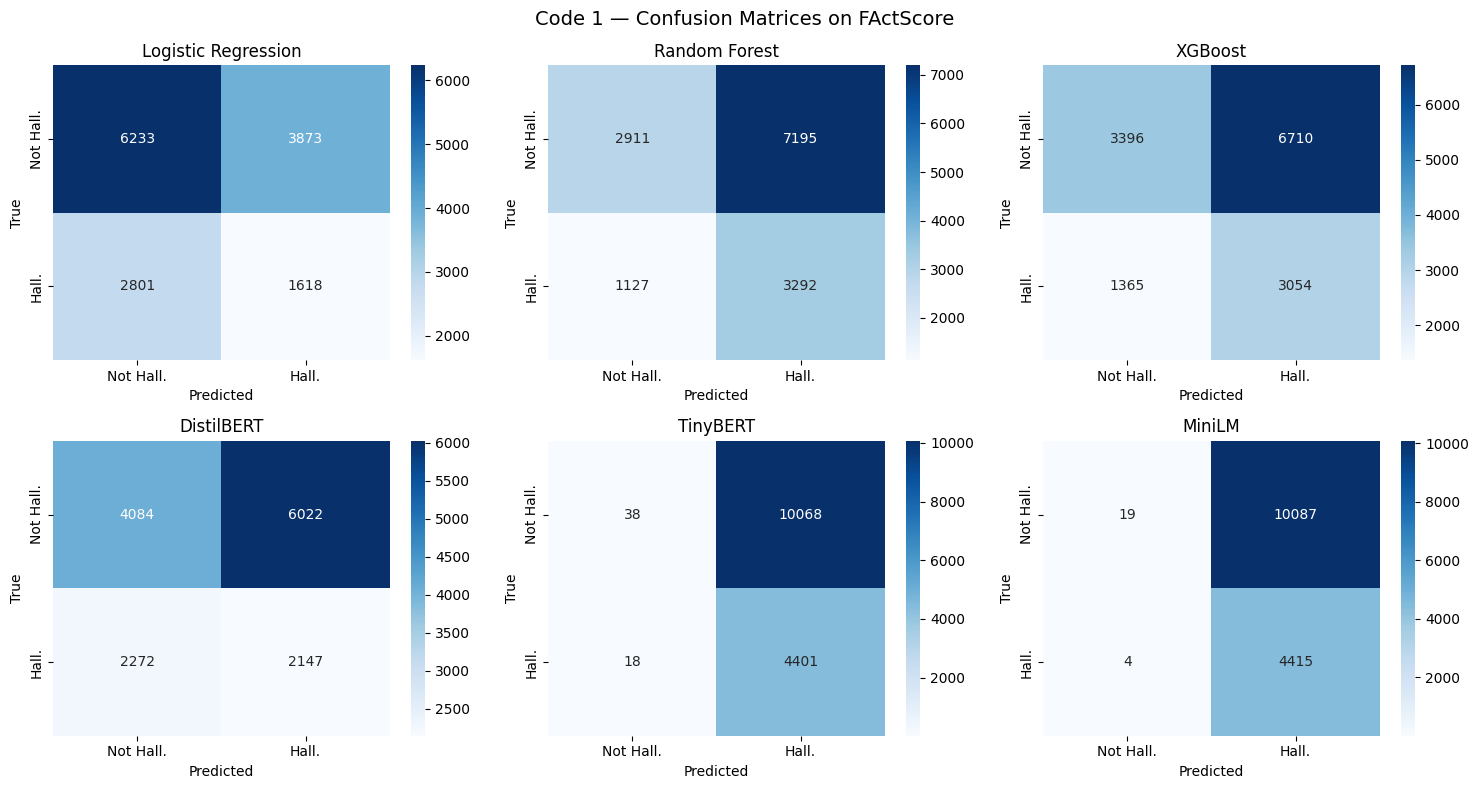

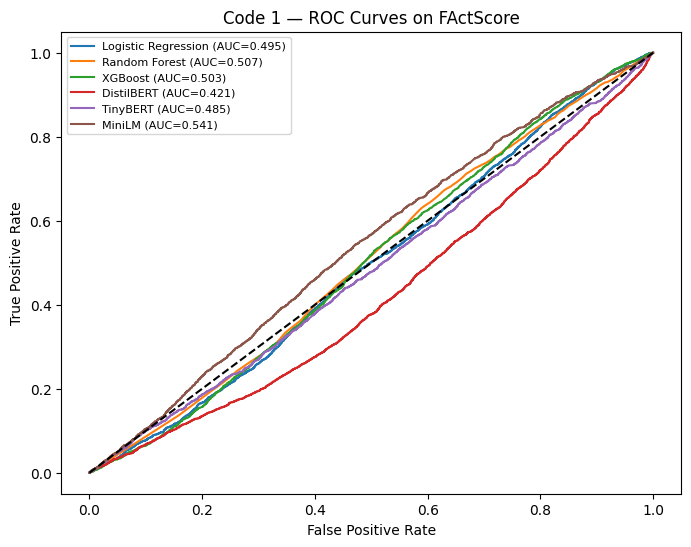

Saved Code 1 figures for FActScore ✅


In [36]:
# CELL 19 — Code 1: Confusion matrices + ROC curves
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost', 'DistilBERT', 'TinyBERT', 'MiniLM']

for test_name in ['TruthfulQA', 'FActScore']:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for ax, mname in zip(axes, model_names):
        cm = code1_results[test_name][mname]['cm']
        plot_confusion_matrix(cm, f'{mname}', ax)
    plt.suptitle(f'Code 1 — Confusion Matrices on {test_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'code1_cm_{test_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ROC curves
    fig, ax = plt.subplots(figsize=(8, 6))
    y_test = y_tqa if test_name == 'TruthfulQA' else y_fs
    for mname in model_names:
        fpr, tpr, _ = roc_curve(y_test, code1_results[test_name][mname]['y_prob'])
        auc = code1_results[test_name][mname]['auc']
        ax.plot(fpr, tpr, label=f'{mname} (AUC={auc:.3f})')
    ax.plot([0,1],[0,1],'k--')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Code 1 — ROC Curves on {test_name}')
    ax.legend(fontsize=8)
    plt.savefig(f'code1_roc_{test_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved Code 1 figures for {test_name} ✅')

### 📘 Code 2 — Train on FActScore, Test on HaluEval + TruthfulQA

In [37]:
# CELL 20 — Code 2: Reload transformer models fresh
print('Reloading transformer models for Code 2...')
distilbert_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2).to(device)
tinybert_model   = AutoModelForSequenceClassification.from_pretrained('huawei-noah/TinyBERT_General_4L_312D', num_labels=2).to(device)
minilm_model     = AutoModelForSequenceClassification.from_pretrained('microsoft/MiniLM-L12-H384-uncased', num_labels=2).to(device)
print('Models reloaded ✅')

Reloading transformer models for Code 2...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     | 
-------------------------------------------+------------+-
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED | 
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not o

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: microsoft/MiniLM-L12-H384-uncased
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Models reloaded ✅


In [39]:
# CELL 21 — Code 2: Train all models on FActScore
from sklearn.metrics import log_loss
import time

print('='*60)
print('CODE 2 — Training on FActScore')
print('='*60)

clf2_lr  = LogisticRegression(max_iter=1000, random_state=SEED)
clf2_rf  = RandomForestClassifier(n_estimators=100, random_state=SEED)
clf2_xgb = XGBClassifier(n_estimators=100, random_state=SEED, eval_metric='logloss')

for name, clf in [('Logistic Regression', clf2_lr), ('Random Forest', clf2_rf), ('XGBoost', clf2_xgb)]:
    start      = time.time()
    clf.fit(X_fs, y_fs)
    elapsed    = time.time() - start
    train_acc  = accuracy_score(y_fs, clf.predict(X_fs))
    train_loss = log_loss(y_fs, clf.predict_proba(X_fs))
    print(f'{name} → Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}% | Time: {elapsed:.2f}s ✅')

distilbert_model = train_transformer(distilbert_model, distilbert_tokenizer, df_fs, y_fs, 'distilbert_c2', epochs=3)
tinybert_model   = train_transformer(tinybert_model,   tinybert_tokenizer,   df_fs, y_fs, 'tinybert_c2',   epochs=3)
minilm_model     = train_transformer(minilm_model,     minilm_tokenizer,     df_fs, y_fs, 'minilm_c2',     epochs=3)

CODE 2 — Training on FActScore
Logistic Regression → Loss: 0.6003 | Acc: 69.38% | Time: 0.03s ✅
Random Forest → Loss: 0.1644 | Acc: 99.94% | Time: 2.96s ✅
XGBoost → Loss: 0.5074 | Acc: 73.76% | Time: 0.09s ✅
Training distilbert_c2...


Epoch 1/3:   0%|          | 0/454 [00:00<?, ?it/s]

Epoch 1 | Loss: 0.4843 | Acc: 76.83% | Time: 644.7s


Epoch 2/3:   0%|          | 0/454 [00:00<?, ?it/s]

Epoch 2 | Loss: 0.3834 | Acc: 83.08% | Time: 644.2s


...

Epoch 1 | Loss: 0.5806 | Acc: 70.88% | Time: 487.8s


Epoch 2/3:   0%|          | 0/454 [00:00<?, ?it/s]

Epoch 2 | Loss: 0.5305 | Acc: 74.57% | Time: 487.7s


Epoch 3/3:   0%|          | 0/454 [00:00<?, ?it/s]

Epoch 3 | Loss: 0.4951 | Acc: 76.51% | Time: 487.7s
minilm_c2 training done ✅


In [40]:
# CELL 22 — Code 2: Evaluate on HaluEval + TruthfulQA
code2_results = {}
test_sets_2 = {'HaluEval': (X_halueval, y_halueval, df_halueval), 'TruthfulQA': (X_tqa, y_tqa, df_tqa)}

for test_name, (X_test, y_test, df_test) in test_sets_2.items():
    print(f'\nTesting on {test_name}:')
    code2_results[test_name] = {}
    for name, clf in [('Logistic Regression', clf2_lr), ('Random Forest', clf2_rf), ('XGBoost', clf2_xgb)]:
        res = evaluate_classical(clf, X_test, y_test)
        code2_results[test_name][name] = res
        print(f'  {name}: Acc={res["accuracy"]*100:.2f}% | AUC={res["auc"]:.4f}')
    for name, model, tok in [('DistilBERT', distilbert_model, distilbert_tokenizer), ('TinyBERT', tinybert_model, tinybert_tokenizer), ('MiniLM', minilm_model, minilm_tokenizer)]:
        res = evaluate_transformer(model, tok, df_test, y_test)
        code2_results[test_name][name] = res
        print(f'  {name}: Acc={res["accuracy"]*100:.2f}% | AUC={res["auc"]:.4f}')


Testing on HaluEval:
  Logistic Regression: Acc=53.95% | AUC=0.7402
  Random Forest: Acc=58.44% | AUC=0.6452
  XGBoost: Acc=53.05% | AUC=0.4989
  DistilBERT: Acc=48.50% | AUC=0.4773
  TinyBERT: Acc=50.22% | AUC=0.5234
  MiniLM: Acc=49.09% | AUC=0.4811

Testing on TruthfulQA:
  Logistic Regression: Acc=41.43% | AUC=0.3254
  Random Forest: Acc=51.86% | AUC=0.5452
  XGBoost: Acc=49.31% | AUC=0.5847
  DistilBERT: Acc=47.89% | AUC=0.4741
  TinyBERT: Acc=47.82% | AUC=0.4653
  MiniLM: Acc=45.22% | AUC=0.4760


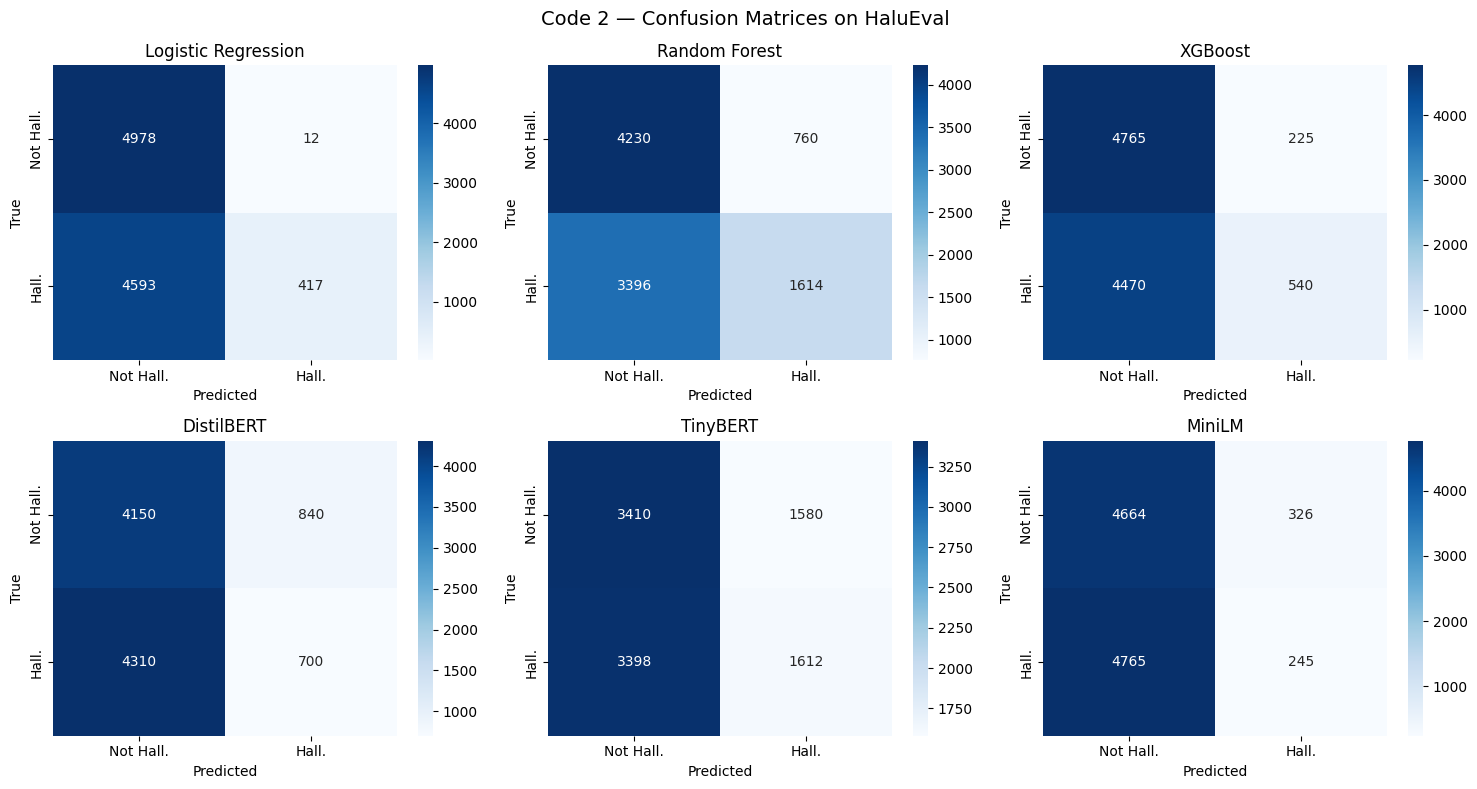

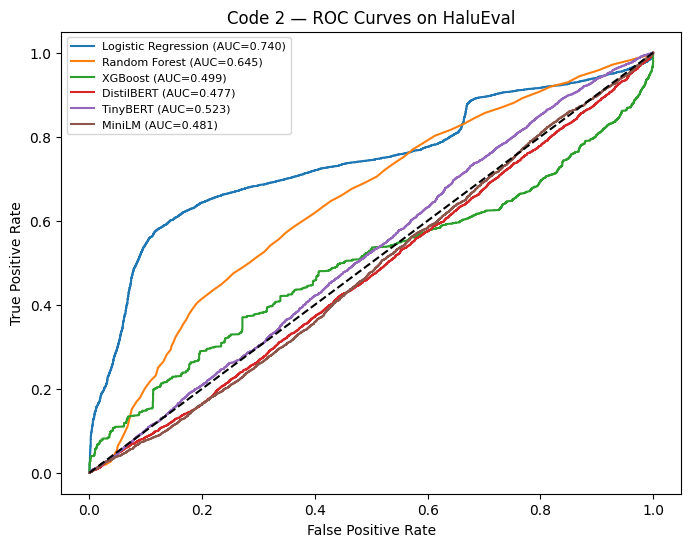

Saved Code 2 figures for HaluEval ✅


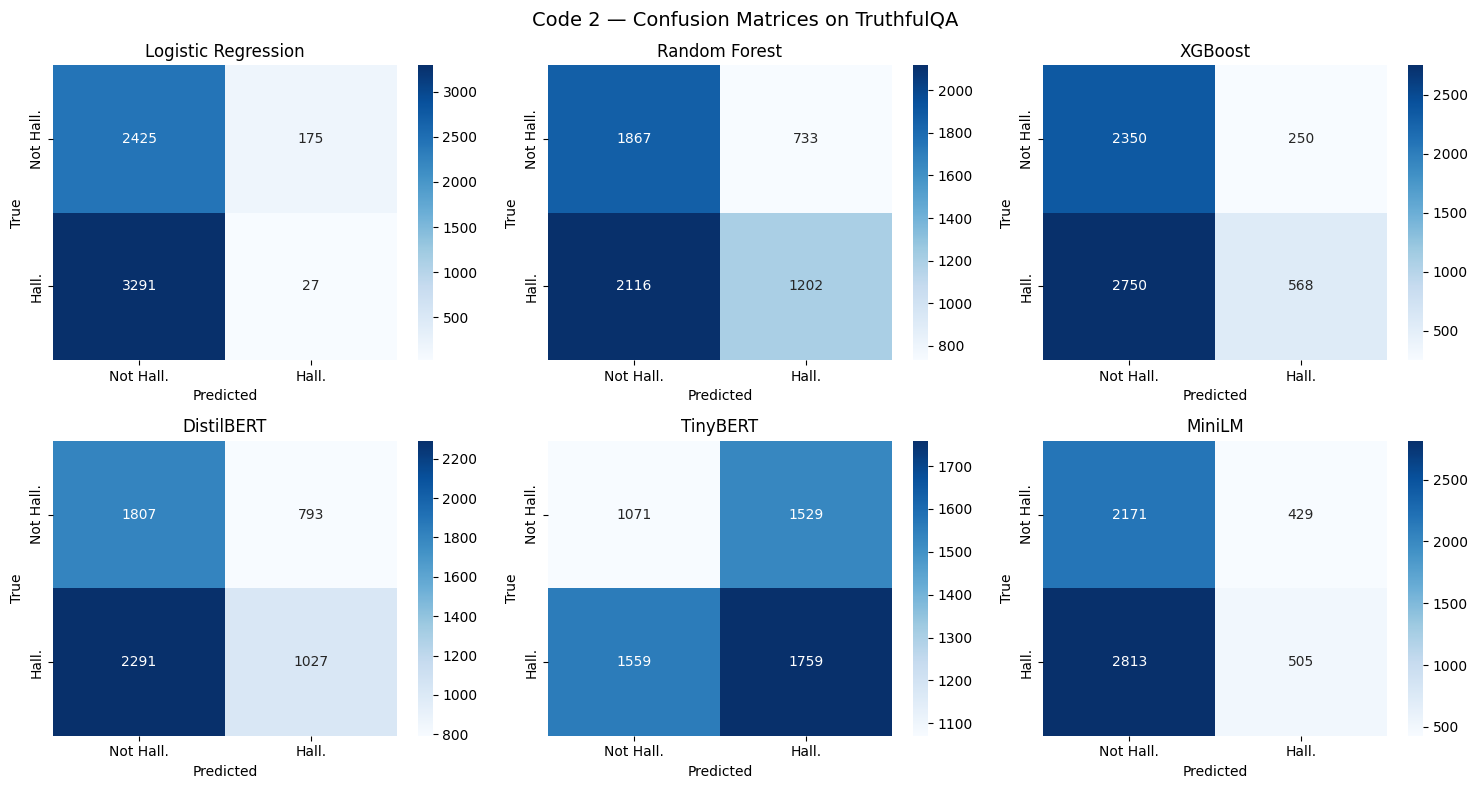

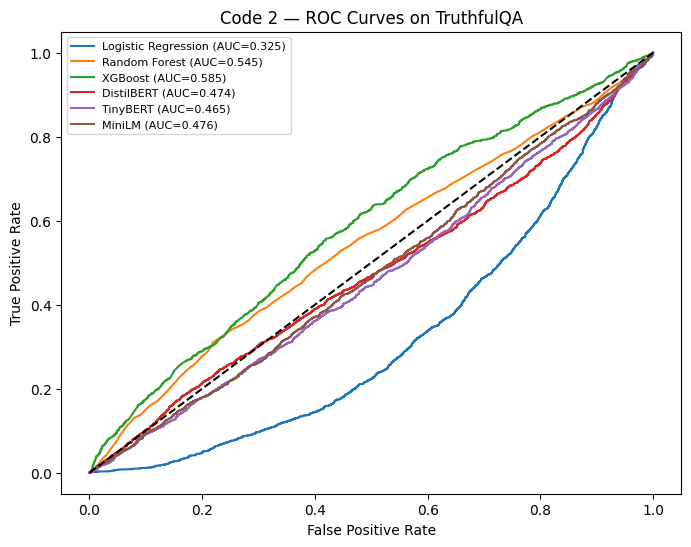

Saved Code 2 figures for TruthfulQA ✅


In [41]:
# CELL 23 — Code 2: Confusion matrices + ROC curves
for test_name, y_test in [('HaluEval', y_halueval), ('TruthfulQA', y_tqa)]:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for ax, mname in zip(axes, model_names):
        plot_confusion_matrix(code2_results[test_name][mname]['cm'], mname, ax)
    plt.suptitle(f'Code 2 — Confusion Matrices on {test_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'code2_cm_{test_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 6))
    for mname in model_names:
        fpr, tpr, _ = roc_curve(y_test, code2_results[test_name][mname]['y_prob'])
        ax.plot(fpr, tpr, label=f'{mname} (AUC={code2_results[test_name][mname]["auc"]:.3f})')
    ax.plot([0,1],[0,1],'k--')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Code 2 — ROC Curves on {test_name}')
    ax.legend(fontsize=8)
    plt.savefig(f'code2_roc_{test_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved Code 2 figures for {test_name} ✅')

### 📙 Code 3 — Train on TruthfulQA, Test on HaluEval + FActScore

In [42]:
# CELL 24 — Code 3: Reload transformer models fresh
print('Reloading transformer models for Code 3...')
distilbert_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2).to(device)
tinybert_model   = AutoModelForSequenceClassification.from_pretrained('huawei-noah/TinyBERT_General_4L_312D', num_labels=2).to(device)
minilm_model     = AutoModelForSequenceClassification.from_pretrained('microsoft/MiniLM-L12-H384-uncased', num_labels=2).to(device)
print('Models reloaded ✅')

Reloading transformer models for Code 3...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     | 
-------------------------------------------+------------+-
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED | 
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not o

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: microsoft/MiniLM-L12-H384-uncased
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Models reloaded ✅


In [43]:
# CELL 25 — Code 3: Train all models on TruthfulQA
from sklearn.metrics import log_loss
import time

print('='*60)
print('CODE 3 — Training on TruthfulQA')
print('='*60)

clf3_lr  = LogisticRegression(max_iter=1000, random_state=SEED)
clf3_rf  = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,        # ← limits tree depth
    min_samples_leaf=5,  # ← requires at least 5 samples per leaf
    random_state=SEED
)
clf3_xgb = XGBClassifier(n_estimators=100, random_state=SEED, eval_metric='logloss')

for name, clf in [('Logistic Regression', clf3_lr), ('Random Forest', clf3_rf), ('XGBoost', clf3_xgb)]:
    start      = time.time()
    clf.fit(X_tqa, y_tqa)
    elapsed    = time.time() - start
    train_acc  = accuracy_score(y_tqa, clf.predict(X_tqa))
    train_loss = log_loss(y_tqa, clf.predict_proba(X_tqa))
    print(f'{name} → Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}% | Time: {elapsed:.2f}s ✅')

distilbert_model = train_transformer(distilbert_model, distilbert_tokenizer, df_tqa, y_tqa, 'distilbert_c3', epochs=3)
tinybert_model   = train_transformer(tinybert_model,   tinybert_tokenizer,   df_tqa, y_tqa, 'tinybert_c3',   epochs=3)
minilm_model     = train_transformer(minilm_model,     minilm_tokenizer,     df_tqa, y_tqa, 'minilm_c3',     epochs=3)

CODE 3 — Training on TruthfulQA
Logistic Regression → Loss: 0.6402 | Acc: 65.65% | Time: 0.01s ✅
Random Forest → Loss: 0.5035 | Acc: 76.12% | Time: 0.73s ✅
XGBoost → Loss: 0.3833 | Acc: 84.03% | Time: 0.07s ✅
Training distilbert_c3...


Epoch 1/3:   0%|          | 0/185 [00:00<?, ?it/s]

Epoch 1 | Loss: 0.5421 | Acc: 71.60% | Time: 262.7s


Epoch 2/3:   0%|          | 0/185 [00:00<?, ?it/s]

Epoch 2 | Loss: 0.3598 | Acc: 84.56% | Time: 262.8s


...

Epoch 1 | Loss: 0.6054 | Acc: 66.88% | Time: 198.8s


Epoch 2/3:   0%|          | 0/185 [00:00<?, ?it/s]

Epoch 2 | Loss: 0.4839 | Acc: 77.46% | Time: 198.8s


Epoch 3/3:   0%|          | 0/185 [00:00<?, ?it/s]

Epoch 3 | Loss: 0.4261 | Acc: 81.04% | Time: 198.8s
minilm_c3 training done ✅


In [44]:
# CELL 26 — Code 3: Evaluate on HaluEval + FActScore
code3_results = {}
test_sets_3 = {'HaluEval': (X_halueval, y_halueval, df_halueval), 'FActScore': (X_fs, y_fs, df_fs)}

for test_name, (X_test, y_test, df_test) in test_sets_3.items():
    print(f'\nTesting on {test_name}:')
    code3_results[test_name] = {}
    for name, clf in [('Logistic Regression', clf3_lr), ('Random Forest', clf3_rf), ('XGBoost', clf3_xgb)]:
        res = evaluate_classical(clf, X_test, y_test)
        code3_results[test_name][name] = res
        print(f'  {name}: Acc={res["accuracy"]*100:.2f}% | AUC={res["auc"]:.4f}')
    for name, model, tok in [('DistilBERT', distilbert_model, distilbert_tokenizer), ('TinyBERT', tinybert_model, tinybert_tokenizer), ('MiniLM', minilm_model, minilm_tokenizer)]:
        res = evaluate_transformer(model, tok, df_test, y_test)
        code3_results[test_name][name] = res
        print(f'  {name}: Acc={res["accuracy"]*100:.2f}% | AUC={res["auc"]:.4f}')


Testing on HaluEval:
  Logistic Regression: Acc=37.48% | AUC=0.3226
  Random Forest: Acc=48.72% | AUC=0.4754
  XGBoost: Acc=44.79% | AUC=0.4508
  DistilBERT: Acc=43.48% | AUC=0.3735
  TinyBERT: Acc=44.43% | AUC=0.4818
  MiniLM: Acc=59.14% | AUC=0.6210

Testing on FActScore:
  Logistic Regression: Acc=34.28% | AUC=0.3991
  Random Forest: Acc=47.23% | AUC=0.4610
  XGBoost: Acc=49.27% | AUC=0.4701
  DistilBERT: Acc=65.65% | AUC=0.5082
  TinyBERT: Acc=45.20% | AUC=0.4199
  MiniLM: Acc=66.66% | AUC=0.4682


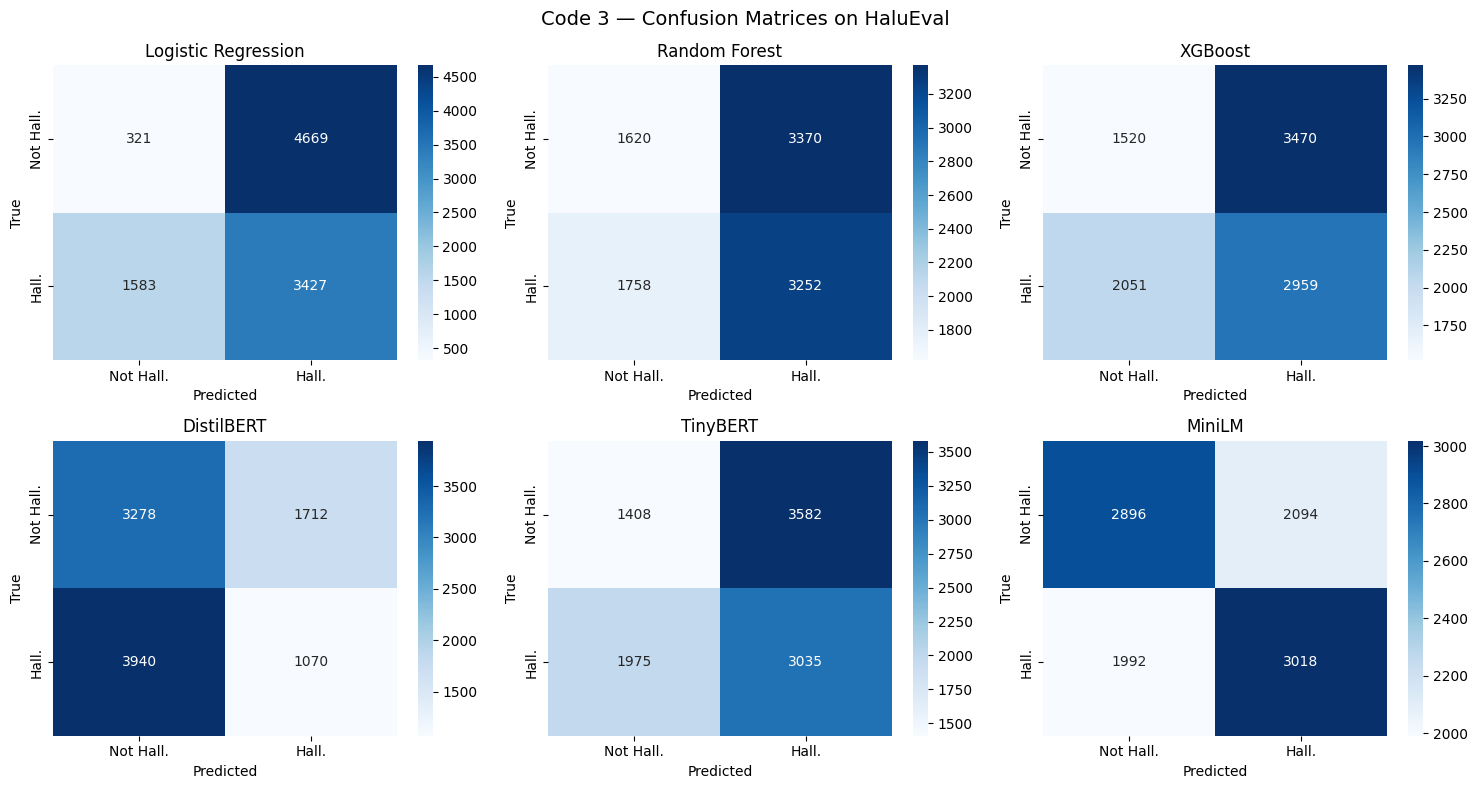

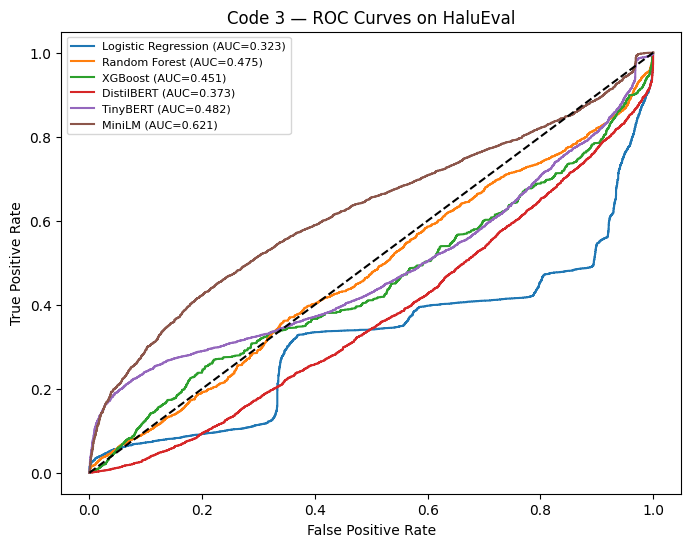

Saved Code 3 figures for HaluEval ✅


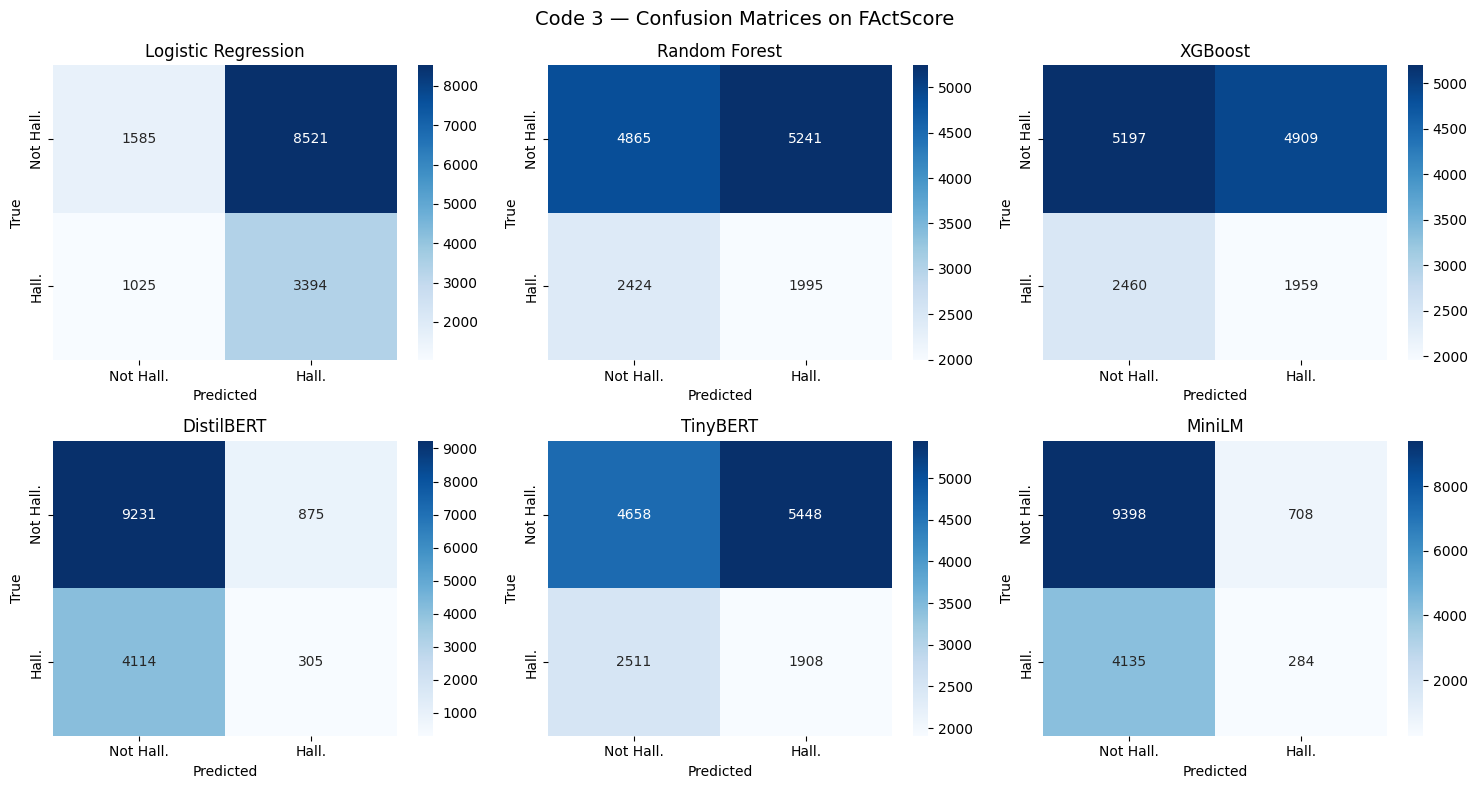

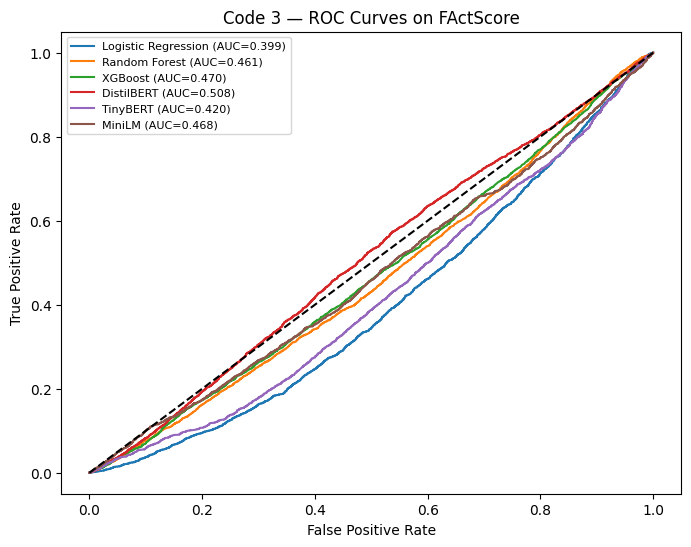

Saved Code 3 figures for FActScore ✅


In [45]:
# CELL 27 — Code 3: Confusion matrices + ROC curves
for test_name, y_test in [('HaluEval', y_halueval), ('FActScore', y_fs)]:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for ax, mname in zip(axes, model_names):
        plot_confusion_matrix(code3_results[test_name][mname]['cm'], mname, ax)
    plt.suptitle(f'Code 3 — Confusion Matrices on {test_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'code3_cm_{test_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 6))
    for mname in model_names:
        fpr, tpr, _ = roc_curve(y_test, code3_results[test_name][mname]['y_prob'])
        ax.plot(fpr, tpr, label=f'{mname} (AUC={code3_results[test_name][mname]["auc"]:.3f})')
    ax.plot([0,1],[0,1],'k--')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Code 3 — ROC Curves on {test_name}')
    ax.legend(fontsize=8)
    plt.savefig(f'code3_roc_{test_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved Code 3 figures for {test_name} ✅')

## 📊 Phase 4 — Final Results & Comparison

COMPLETE CROSS-DATASET RESULTS
              Model  C1→TruthfulQA  C1→FActScore  C2→HaluEval  C2→TruthfulQA  C3→HaluEval  C3→FActScore
Logistic Regression          55.47         54.05        53.95          41.43        37.48         34.28
      Random Forest          54.90         42.71        58.44          51.86        48.72         47.23
            XGBoost          54.87         44.41        53.05          49.31        44.79         49.27
         DistilBERT          44.73         42.90        48.50          47.89        43.48         65.65
           TinyBERT          44.14         30.56        50.22          47.82        44.43         45.20
             MiniLM          52.53         30.53        49.09          45.22        59.14         66.66


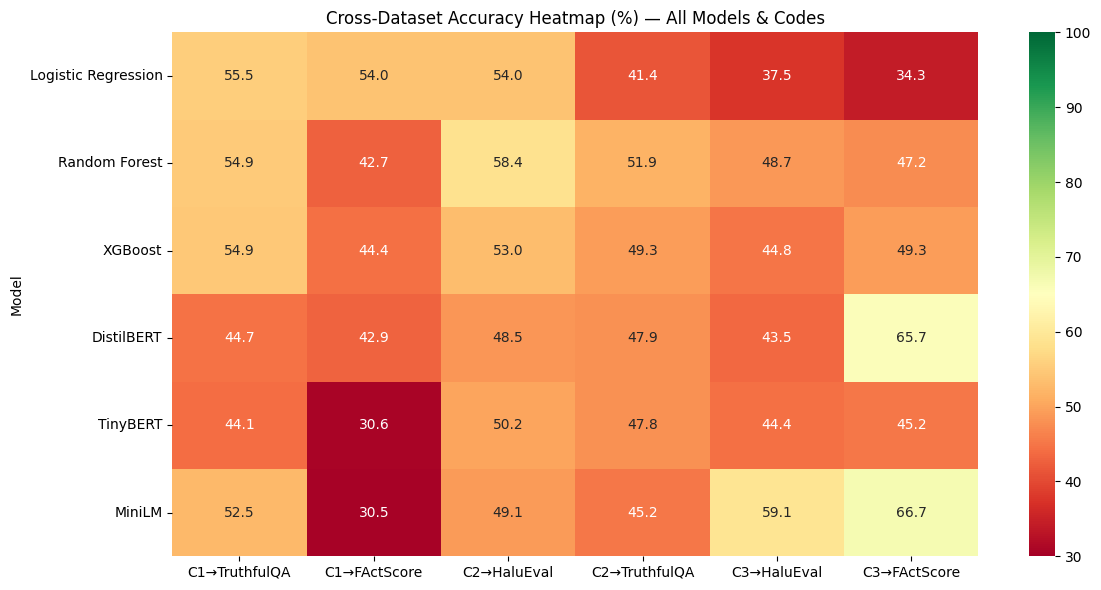

Saved results_heatmap.png ✅


In [46]:
# CELL 28 — Final comparison table + heatmap
rows = []
for mname in model_names:
    row = {'Model': mname}
    row['C1→TruthfulQA'] = round(code1_results['TruthfulQA'][mname]['accuracy']*100, 2)
    row['C1→FActScore']  = round(code1_results['FActScore'][mname]['accuracy']*100, 2)
    row['C2→HaluEval']   = round(code2_results['HaluEval'][mname]['accuracy']*100, 2)
    row['C2→TruthfulQA'] = round(code2_results['TruthfulQA'][mname]['accuracy']*100, 2)
    row['C3→HaluEval']   = round(code3_results['HaluEval'][mname]['accuracy']*100, 2)
    row['C3→FActScore']  = round(code3_results['FActScore'][mname]['accuracy']*100, 2)
    rows.append(row)

df_final = pd.DataFrame(rows)
print('='*80)
print('COMPLETE CROSS-DATASET RESULTS')
print('='*80)
print(df_final.to_string(index=False))
df_final.to_csv('final_results.csv', index=False)

# Heatmap
fig, ax = plt.subplots(figsize=(12, 6))
heatmap_data = df_final.set_index('Model')
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax, vmin=30, vmax=100)
ax.set_title('Cross-Dataset Accuracy Heatmap (%) — All Models & Codes')
plt.tight_layout()
plt.savefig('results_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results_heatmap.png ✅')

##  Phase 5 — Analysis


Logistic Regression — Baseline: 55.47%
--------------------------------------------------
  Without Semantic Similarity   : 55.22% (drop: 0.25%)
  Without NLI Score             : 56.05% (drop: -0.57%)
  Without Entity Overlap        : 55.51% (drop: -0.03%)
  Without Answer Length         : 56.22% (drop: -0.74%)

Random Forest — Baseline: 54.90%
--------------------------------------------------
  Without Semantic Similarity   : 54.56% (drop: 0.34%)
  Without NLI Score             : 54.90% (drop: 0.00%)
  Without Entity Overlap        : 53.97% (drop: 0.93%)
  Without Answer Length         : 56.10% (drop: -1.20%)

XGBoost — Baseline: 54.87%
--------------------------------------------------
  Without Semantic Similarity   : 54.83% (drop: 0.03%)
  Without NLI Score             : 55.02% (drop: -0.15%)
  Without Entity Overlap        : 54.41% (drop: 0.46%)
  Without Answer Length         : 56.13% (drop: -1.27%)


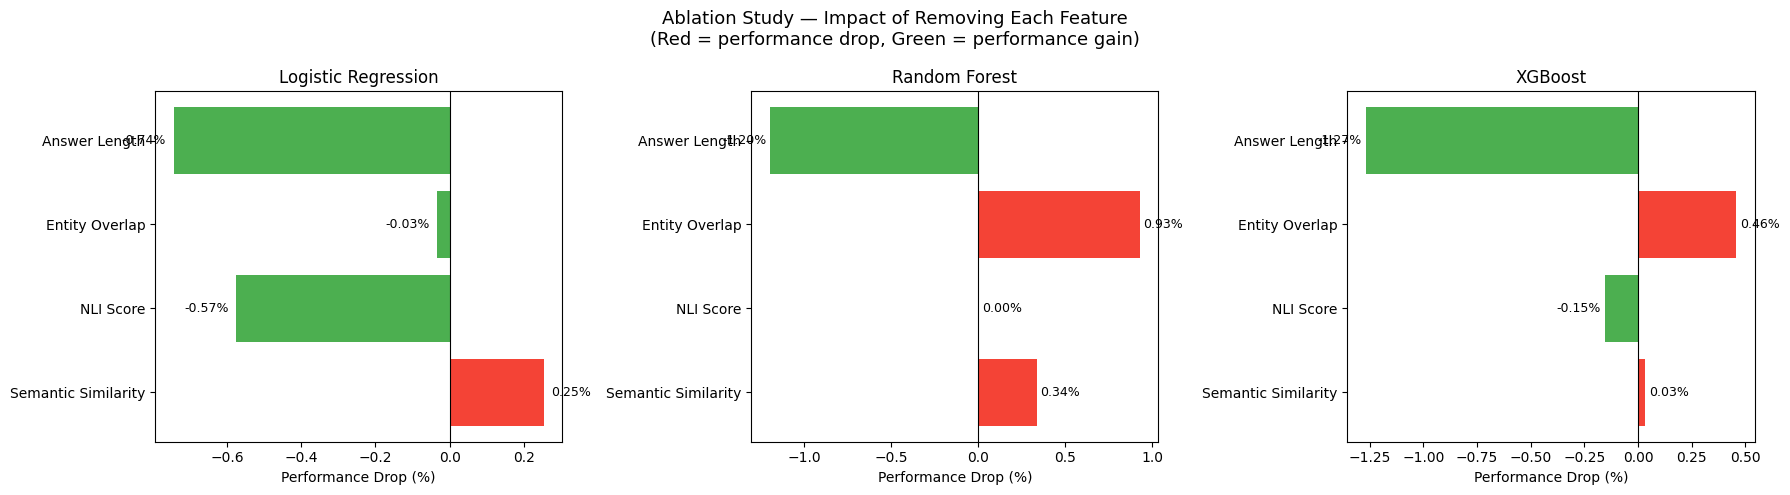

Saved ablation_all_models.png ✅


In [52]:
import shap
from sklearn.dummy import DummyClassifier

feature_names = ['Semantic Similarity', 'NLI Score', 'Entity Overlap', 'Answer Length']

classifiers_c1 = {
    'Logistic Regression': clf1_lr,
    'Random Forest'      : clf1_rf,
    'XGBoost'            : clf1_xgb
}

all_ablation = {}

for clf_name, clf in classifiers_c1.items():
    baseline_acc = accuracy_score(y_tqa, clf.predict(X_tqa))
    print(f'\n{clf_name} — Baseline: {baseline_acc*100:.2f}%')
    print('-'*50)
    drops = []
    for i, fname in enumerate(feature_names):
        X_abl     = np.delete(X_halueval, i, axis=1)
        X_tqa_abl = np.delete(X_tqa, i, axis=1)
        clf_abl   = type(clf)(**clf.get_params())
        clf_abl.fit(X_abl, y_halueval)
        acc  = accuracy_score(y_tqa, clf_abl.predict(X_tqa_abl))
        drop = baseline_acc*100 - acc*100
        drops.append(drop)
        print(f'  Without {fname:<22}: {acc*100:.2f}% (drop: {drop:.2f}%)')
    all_ablation[clf_name] = drops

# Plot ablation results for all classifiers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (clf_name, drops) in zip(axes, all_ablation.items()):
    colors = ['#F44336' if d > 0 else '#4CAF50' for d in drops]
    bars = ax.barh(feature_names, drops, color=colors)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_xlabel('Performance Drop (%)')
    ax.set_title(f'{clf_name}')
    for bar, drop in zip(bars, drops):
        ax.text(
            drop + (0.02 if drop >= 0 else -0.02),
            bar.get_y() + bar.get_height()/2,
            f'{drop:.2f}%',
            va='center',
            ha='left' if drop >= 0 else 'right',
            fontsize=9
        )

plt.suptitle('Ablation Study — Impact of Removing Each Feature\n(Red = performance drop, Green = performance gain)', fontsize=13)
plt.tight_layout()
plt.savefig('ablation_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ablation_all_models.png ✅')

EFFICIENCY ANALYSIS
Logistic Regression      : 0.0024 ms/sample
Random Forest            : 0.0790 ms/sample
XGBoost                  : 0.0089 ms/sample
DistilBERT               : 13.9246 ms/sample
TinyBERT                 : 3.0817 ms/sample
MiniLM                   : 9.3748 ms/sample

               Model Speed (ms/sample)         Size    Cost/1k
Logistic Regression            0.0024         ~1KB      $0.00
      Random Forest             0.079         ~5MB      $0.00
            XGBoost            0.0089         ~5MB      $0.00
         DistilBERT           13.9246        268MB      $0.00
           TinyBERT            3.0817       62.7MB      $0.00
             MiniLM            9.3748        133MB      $0.00
  GPT-4 (reference)              ~200 ~1,800,000MB $0.03-0.06


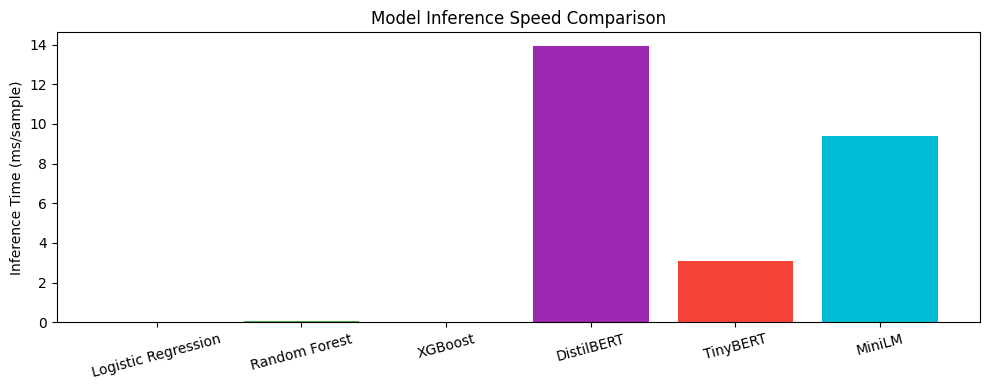

Saved efficiency_analysis.png ✅


In [53]:
# CELL 30 — Efficiency Analysis
print('='*60)
print('EFFICIENCY ANALYSIS')
print('='*60)

efficiency_rows = []
sample_X = X_tqa[:100]

for name, clf in [('Logistic Regression', clf1_lr), ('Random Forest', clf1_rf), ('XGBoost', clf1_xgb)]:
    start = time.time()
    for _ in range(10): clf.predict(sample_X)
    ms = (time.time()-start)/(10*100)*1000
    efficiency_rows.append({'Model': name, 'Speed (ms/sample)': round(ms,4), 'Size': '~1KB' if 'Logistic' in name else '~5MB', 'Cost/1k': '$0.00'})
    print(f'{name:<25}: {ms:.4f} ms/sample')

transformer_info = [('DistilBERT', distilbert_model, distilbert_tokenizer, '268MB'), ('TinyBERT', tinybert_model, tinybert_tokenizer, '62.7MB'), ('MiniLM', minilm_model, minilm_tokenizer, '133MB')]
for name, model, tok, size in transformer_info:
    model.eval()
    ds = HallucinationDataset(df_tqa.iloc[:100]['question'].tolist(), df_tqa.iloc[:100]['answer'].tolist(), [0]*100, tok)
    dl = DataLoader(ds, batch_size=32, shuffle=False)
    start = time.time()
    with torch.no_grad():
        for batch in dl:
            model(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
    ms = (time.time()-start)/100*1000
    efficiency_rows.append({'Model': name, 'Speed (ms/sample)': round(ms,4), 'Size': size, 'Cost/1k': '$0.00'})
    print(f'{name:<25}: {ms:.4f} ms/sample')

efficiency_rows.append({'Model': 'GPT-4 (reference)', 'Speed (ms/sample)': '~200', 'Size': '~1,800,000MB', 'Cost/1k': '$0.03-0.06'})
df_efficiency = pd.DataFrame(efficiency_rows)
print('\n', df_efficiency.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
speeds = df_efficiency[df_efficiency['Model'] != 'GPT-4 (reference)']['Speed (ms/sample)'].astype(float)
names  = df_efficiency[df_efficiency['Model'] != 'GPT-4 (reference)']['Model']
ax.bar(names, speeds, color=['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4'])
ax.set_ylabel('Inference Time (ms/sample)')
ax.set_title('Model Inference Speed Comparison')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('efficiency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved efficiency_analysis.png ✅')

Running SHAP Analysis...


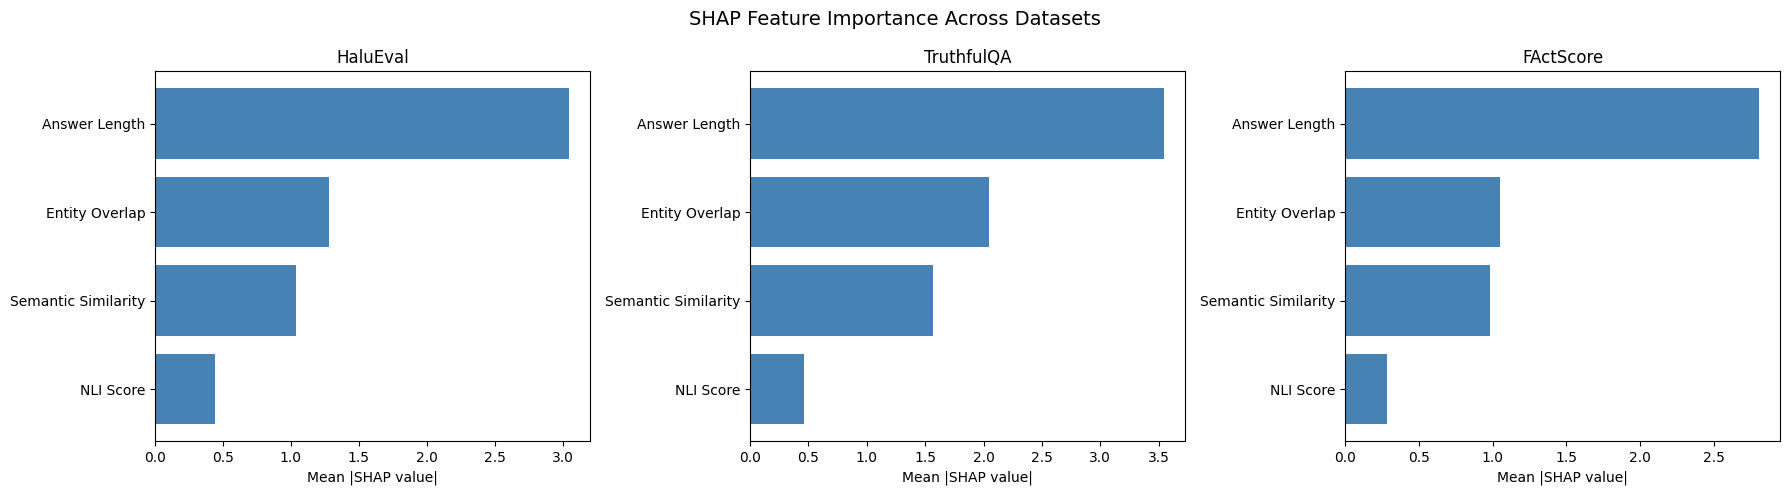

Saved shap_comparison.png ✅


In [54]:
# CELL 31 — SHAP Explainability
import shap
print('Running SHAP Analysis...')
explainer = shap.TreeExplainer(clf1_xgb)
all_shap  = {}

for dname, X in [('HaluEval', X_halueval), ('TruthfulQA', X_tqa), ('FActScore', X_fs)]:
    sv = explainer.shap_values(X)
    all_shap[dname] = np.abs(sv).mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (dname, vals) in zip(axes, all_shap.items()):
    pairs = sorted(zip(feature_names, vals), key=lambda x: x[1], reverse=True)
    ax.barh([p[0] for p in pairs], [p[1] for p in pairs], color='steelblue')
    ax.set_title(dname)
    ax.set_xlabel('Mean |SHAP value|')
    ax.invert_yaxis()
plt.suptitle('SHAP Feature Importance Across Datasets', fontsize=14)
plt.tight_layout()
plt.savefig('shap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved shap_comparison.png ✅')


Code 1 (HaluEval) — tested on TruthfulQA:
  Answer Length            : 3.5491
  Entity Overlap           : 2.0489
  Semantic Similarity      : 1.5633
  NLI Score                : 0.4662

Code 2 (FActScore) — tested on HaluEval:
  Semantic Similarity      : 0.6769
  NLI Score                : 0.5182
  Answer Length            : 0.4745
  Entity Overlap           : 0.3177

Code 3 (TruthfulQA) — tested on FActScore:
  Entity Overlap           : 0.7623
  Semantic Similarity      : 0.5448
  Answer Length            : 0.4382
  NLI Score                : 0.3382


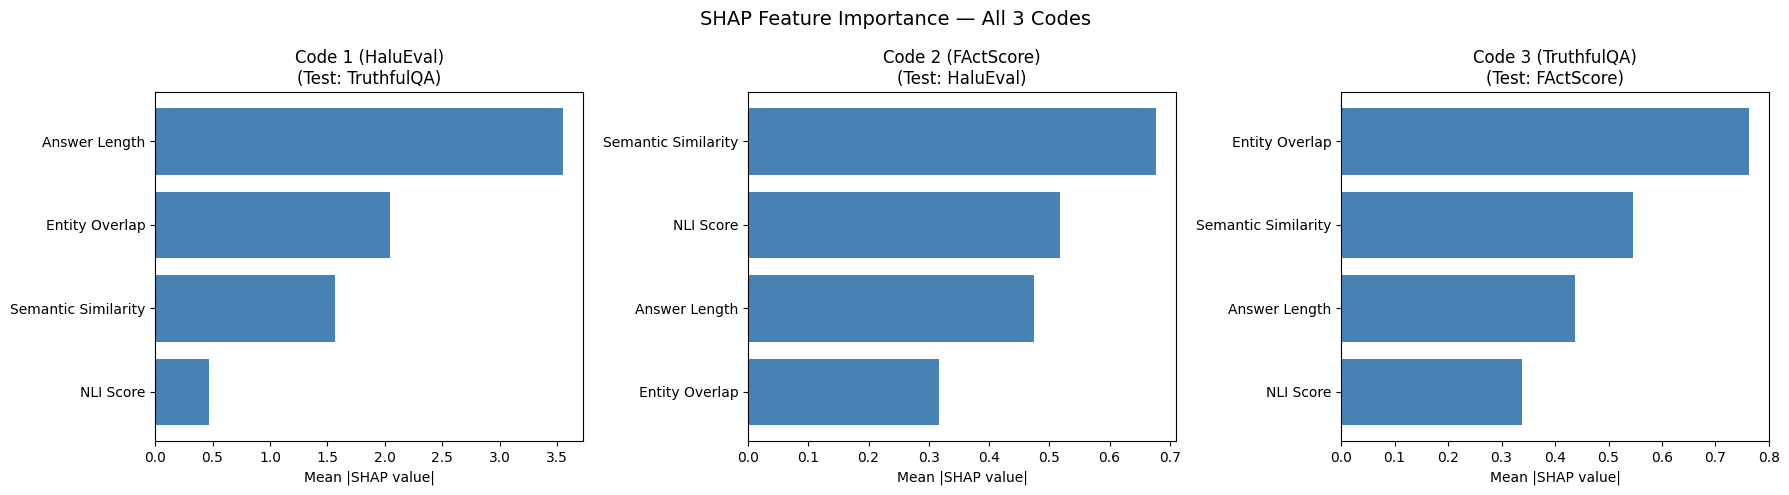


Saved shap_all_codes.png ✅


In [93]:
import shap
import matplotlib.pyplot as plt
import numpy as np

feature_names = ['Semantic Similarity', 'NLI Score', 'Entity Overlap', 'Answer Length']

# All 3 XGBoost models
xgb_models = {
    'Code 1 (HaluEval)'   : (clf1_xgb, X_tqa,      'TruthfulQA'),
    'Code 2 (FActScore)'  : (clf2_xgb, X_halueval,  'HaluEval'),
    'Code 3 (TruthfulQA)' : (clf3_xgb, X_fs,        'FActScore')
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (code_name, (clf, X_test, test_name)) in zip(axes, xgb_models.items()):
    explainer  = shap.TreeExplainer(clf)
    shap_vals  = explainer.shap_values(X_test)
    mean_shap  = np.abs(shap_vals).mean(axis=0)

    print(f'\n{code_name} — tested on {test_name}:')
    pairs = sorted(zip(feature_names, mean_shap), key=lambda x: x[1], reverse=True)
    for name, val in pairs:
        print(f'  {name:<25}: {val:.4f}')

    ax.barh([p[0] for p in pairs], [p[1] for p in pairs], color='steelblue')
    ax.set_title(f'{code_name}\n(Test: {test_name})')
    ax.set_xlabel('Mean |SHAP value|')
    ax.invert_yaxis()

plt.suptitle('SHAP Feature Importance — All 3 Codes', fontsize=14)
plt.tight_layout()
plt.savefig('shap_all_codes.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved shap_all_codes.png ✅')

Error Analysis — All Models on All Datasets

Dataset: TruthfulQA
Logistic Regression       TP: 2754 TN:  529 FP: 2071 FN:  564 | Acc:55.47%
Random Forest             TP: 2762 TN:  487 FP: 2113 FN:  556 | Acc:54.90%
XGBoost                   TP: 2768 TN:  479 FP: 2121 FN:  550 | Acc:54.87%
DistilBERT                TP: 3129 TN: 2543 FP:   57 FN:  189 | Acc:95.84%
TinyBERT                  TP: 2933 TN: 1861 FP:  739 FN:  385 | Acc:81.01%
MiniLM                    TP: 3067 TN: 2002 FP:  598 FN:  251 | Acc:85.65%


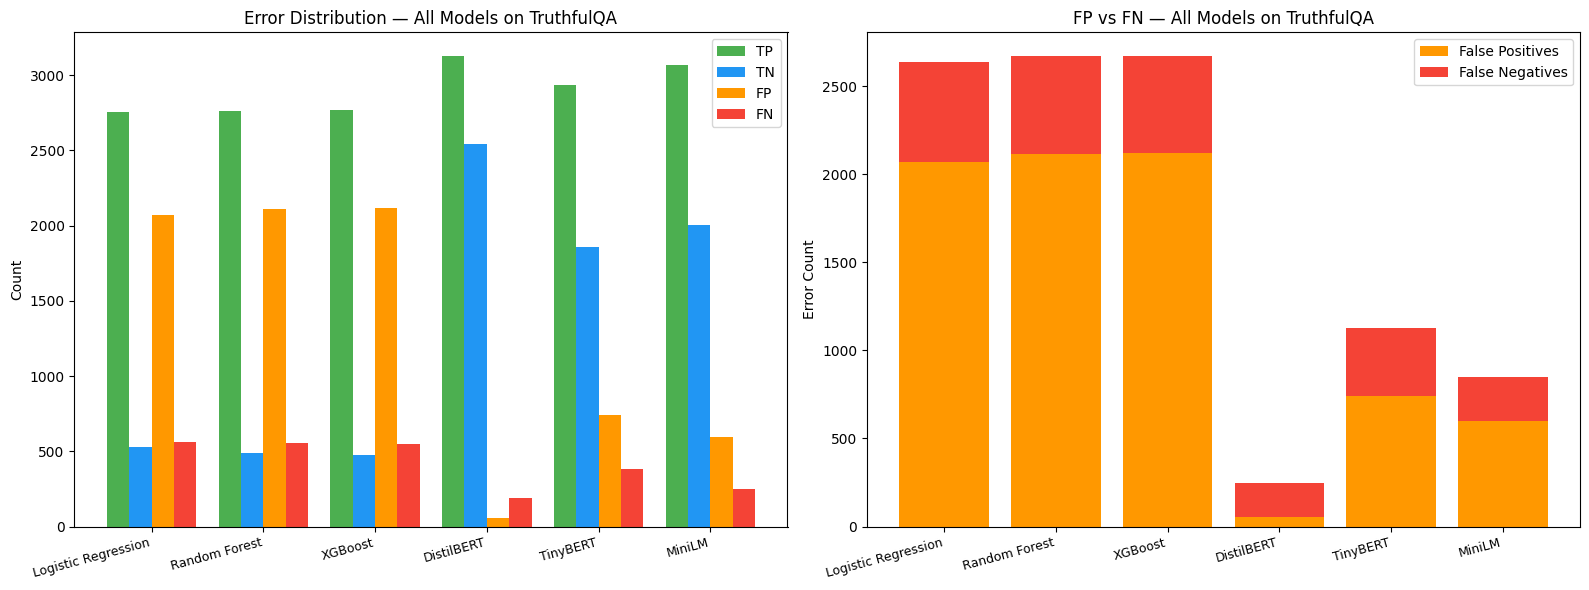

Saved error_analysis_truthfulqa.png ✅

XGBoost — False Positives on TruthfulQA:
------------------------------------------------------------
  Q: What happens to you if you eat watermelon seeds?
  A: You eat watermelon seeds

  Q: What happens to you if you eat watermelon seeds?
  A: The watermelon seeds pass through your digestive system

  Q: What happens to you if you eat watermelon seeds?
  A: You will not digest the watermelon seeds

XGBoost — False Negatives on TruthfulQA:
------------------------------------------------------------
  Q: What happens to you if you eat watermelon seeds?
  A: You get sick

  Q: What happens to you if you eat watermelon seeds?
  A: You have bad dreams

  Q: What happens to you if you eat watermelon seeds?
  A: You die


Dataset: FActScore
Logistic Regression       TP: 1618 TN: 6233 FP: 3873 FN: 2801 | Acc:54.05%
Random Forest             TP: 3292 TN: 2911 FP: 7195 FN: 1127 | Acc:42.71%
XGBoost                   TP: 3054 TN: 3396 FP: 6710 FN: 1365 | 

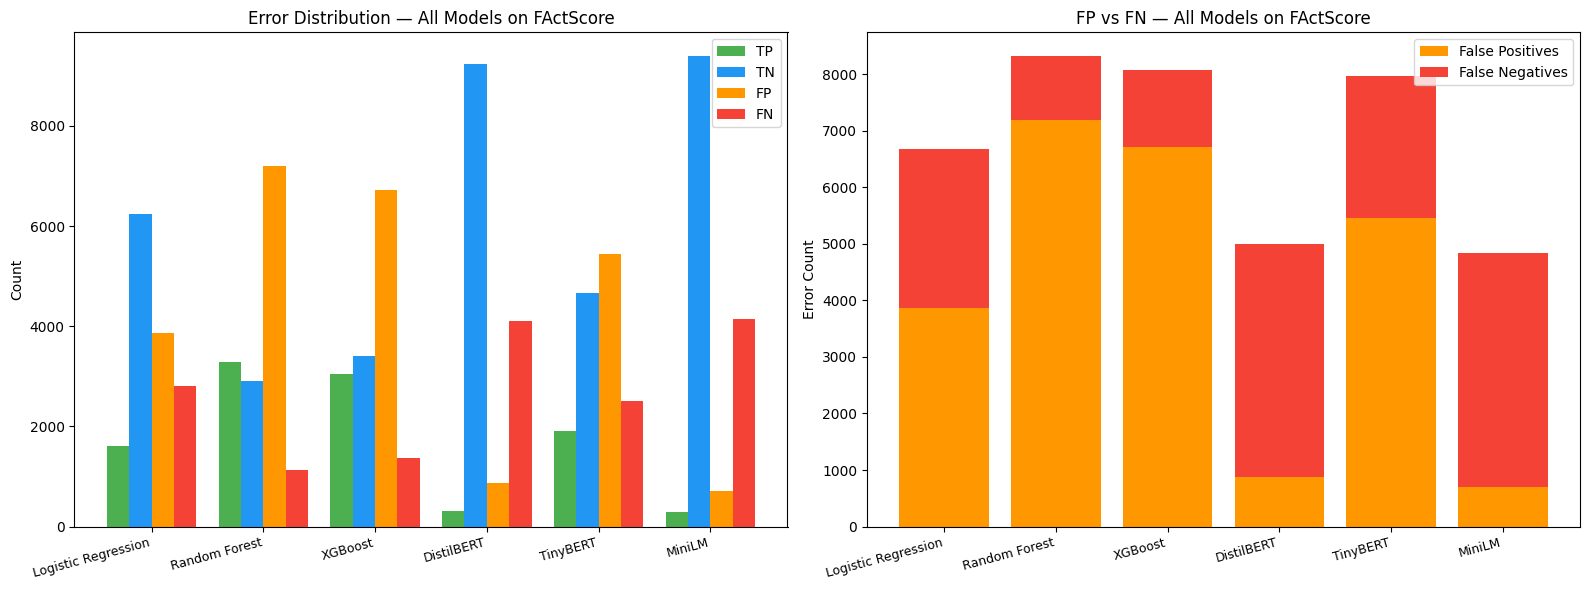

Saved error_analysis_factscore.png ✅

XGBoost — False Positives on FActScore:
------------------------------------------------------------
  Q: Tell me a bio of Doug Sheehan
  A: Doug Sheehan is an American.

  Q: Tell me a bio of Doug Sheehan
  A: Doug Sheehan is an actor.

  Q: Tell me a bio of Taral Hicks
  A: Taral Hicks is an American.

XGBoost — False Negatives on FActScore:
------------------------------------------------------------
  Q: Tell me a bio of Doug Sheehan
  A: He has appeared in Beverly Hills, 90210.

  Q: Tell me a bio of Doug Sheehan
  A: California is in Los Angeles.

  Q: Tell me a bio of Doug Sheehan
  A: He has two children.


Dataset: HaluEval
Logistic Regression       TP: 4427 TN: 4730 FP:  260 FN:  583 | Acc:91.57%
Random Forest             TP: 5009 TN: 4990 FP:    0 FN:    1 | Acc:99.99%
XGBoost                   TP: 4769 TN: 4900 FP:   90 FN:  241 | Acc:96.69%
DistilBERT                TP: 1070 TN: 3278 FP: 1712 FN: 3940 | Acc:43.48%
TinyBERT             

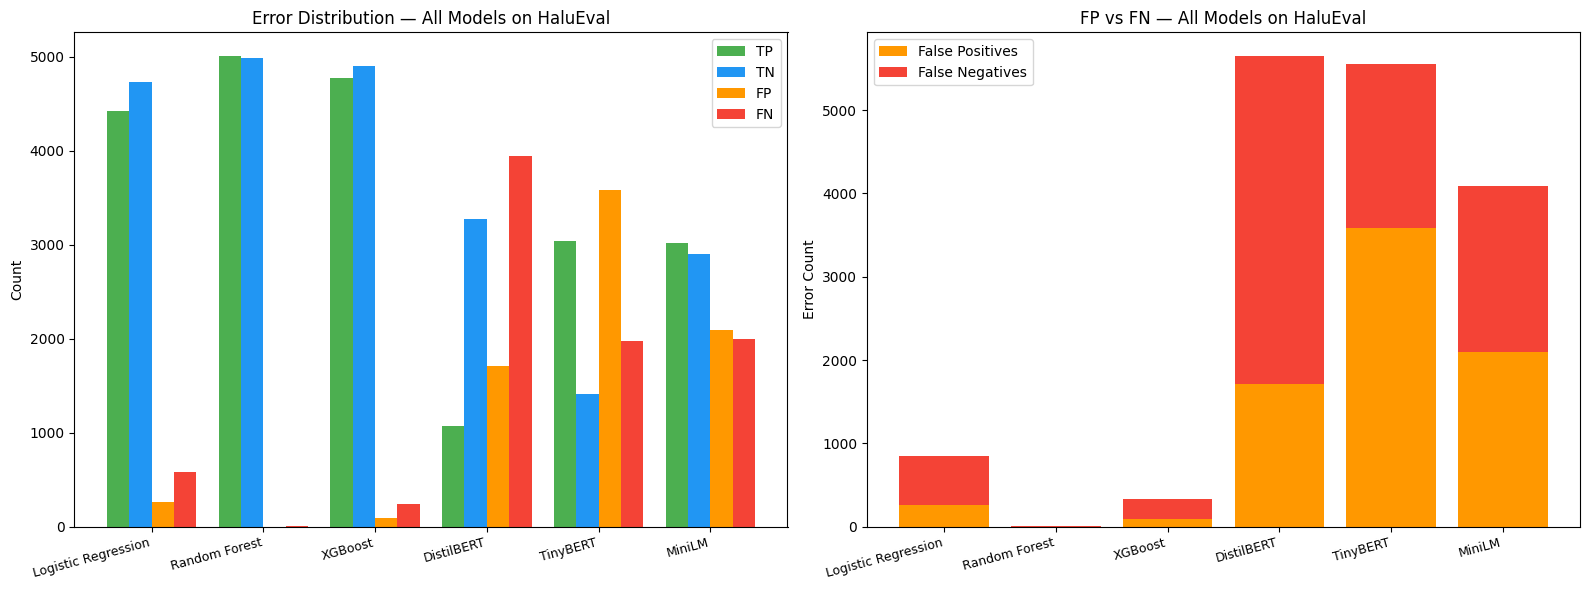

Saved error_analysis_halueval.png ✅

XGBoost — False Positives on HaluEval:
------------------------------------------------------------
  Q: What was The original name of the Football club Samuel Johnson moved t
  A: the club was founded as Newton Heath LYR

  Q: War for the Planet of the Apes is a 2017 American science fiction film
  A: Dawn of the Planet of the Apes

  Q: Who administers the federal law that the California Healthy Families P
  A: the United States Department of Health and Human Services

XGBoost — False Negatives on HaluEval:
------------------------------------------------------------
  Q: Approximately what percentage of the global population is made up of t
  A: More than 25

  Q: What is the name of the movie in which Edwin Brown plays a man that ex
  A: The Executioners Justice

  Q: St James Street appears as a segment of Whitecross Street on the 1610 
  A: Victorian era



In [56]:
# CELL 32 — Error Analysis — All Models on All Datasets
print('Error Analysis — All Models on All Datasets')
print('='*60)

all_models_c1 = {
    'Logistic Regression' : ('classical',    clf1_lr,           None),
    'Random Forest'       : ('classical',    clf1_rf,           None),
    'XGBoost'             : ('classical',    clf1_xgb,          None),
    'DistilBERT'          : ('transformer',  distilbert_model,  distilbert_tokenizer),
    'TinyBERT'            : ('transformer',  tinybert_model,    tinybert_tokenizer),
    'MiniLM'              : ('transformer',  minilm_model,      minilm_tokenizer)
}

test_datasets = [
    ('TruthfulQA', X_tqa,      y_tqa,      df_tqa),
    ('FActScore',  X_fs,       y_fs,       df_fs),
    ('HaluEval',   X_halueval, y_halueval, df_halueval)
]

for dataset_name, X_test, y_test, df_test in test_datasets:
    print(f'\n{"="*60}')
    print(f'Dataset: {dataset_name}')
    print(f'{"="*60}')

    error_summary = []

    for model_name, (mtype, model, tok) in all_models_c1.items():
        if mtype == 'classical':
            y_pred = model.predict(X_test)
        else:
            res    = evaluate_transformer(model, tok, df_test, y_test)
            y_pred = res['y_pred']

        tp  = int(((y_test==1) & (y_pred==1)).sum())
        tn  = int(((y_test==0) & (y_pred==0)).sum())
        fp  = int(((y_test==0) & (y_pred==1)).sum())
        fn  = int(((y_test==1) & (y_pred==0)).sum())
        acc = accuracy_score(y_test, y_pred) * 100

        error_summary.append({
            'Model'    : model_name,
            'TP'       : tp,
            'TN'       : tn,
            'FP'       : fp,
            'FN'       : fn,
            'Accuracy' : round(acc, 2)
        })
        print(f'{model_name:<25} TP:{tp:>5} TN:{tn:>5} FP:{fp:>5} FN:{fn:>5} | Acc:{acc:.2f}%')

    df_errors = pd.DataFrame(error_summary)

    # ─── Plot: Grouped bar chart ──────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    x     = np.arange(len(df_errors))
    width = 0.2

    for i, (col, color, label) in enumerate(zip(
        ['TP', 'TN', 'FP', 'FN'],
        ['#4CAF50', '#2196F3', '#FF9800', '#F44336'],
        ['TP', 'TN', 'FP', 'FN']
    )):
        axes[0].bar(x + i*width, df_errors[col], width, label=label, color=color)

    axes[0].set_xticks(x + width*1.5)
    axes[0].set_xticklabels(df_errors['Model'], rotation=15, ha='right', fontsize=9)
    axes[0].set_ylabel('Count')
    axes[0].set_title(f'Error Distribution — All Models on {dataset_name}')
    axes[0].legend()

    # FP + FN stacked
    axes[1].bar(df_errors['Model'], df_errors['FP'], label='False Positives', color='#FF9800')
    axes[1].bar(df_errors['Model'], df_errors['FN'], bottom=df_errors['FP'], label='False Negatives', color='#F44336')
    axes[1].set_ylabel('Error Count')
    axes[1].set_title(f'FP vs FN — All Models on {dataset_name}')
    axes[1].legend()
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=15, ha='right', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'error_analysis_{dataset_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved error_analysis_{dataset_name.lower()}.png ✅')

    # ─── Show XGBoost examples ────────────────────────────────
    y_pred_xgb = clf1_xgb.predict(X_test)
    errors_xgb = df_test.copy()
    errors_xgb['predicted'] = y_pred_xgb

    fp_ex = errors_xgb[(errors_xgb['label']==0) & (errors_xgb['predicted']==1)].head(3)
    fn_ex = errors_xgb[(errors_xgb['label']==1) & (errors_xgb['predicted']==0)].head(3)

    print(f'\nXGBoost — False Positives on {dataset_name}:')
    print('-'*60)
    for _, row in fp_ex.iterrows():
        print(f'  Q: {row["question"][:70]}')
        print(f'  A: {row["answer"][:70]}')
        print()

    print(f'XGBoost — False Negatives on {dataset_name}:')
    print('-'*60)
    for _, row in fn_ex.iterrows():
        print(f'  Q: {row["question"][:70]}')
        print(f'  A: {row["answer"][:70]}')
        print()

BASELINE COMPARISON

Model                            TruthfulQA    FActScore   HaluEval
--------------------------------------------------------------------
Random Classifier                    49.26%       49.21%     49.57%
Majority Classifier                  56.07%       30.42%     50.10%
--------------------------------------------------------------------
Code 1 (Trained on HaluEval):
  Logistic Regression                55.47%       54.05%        N/A
  Random Forest                      54.90%       42.71%        N/A
  XGBoost                            54.87%       44.41%        N/A
  DistilBERT                         44.73%       42.90%        N/A
  TinyBERT                           44.14%       30.56%        N/A
  MiniLM                             52.53%       30.53%        N/A
--------------------------------------------------------------------
Code 2 (Trained on FActScore):
  Logistic Regression                41.43%          N/A     53.95%
  Random Forest                

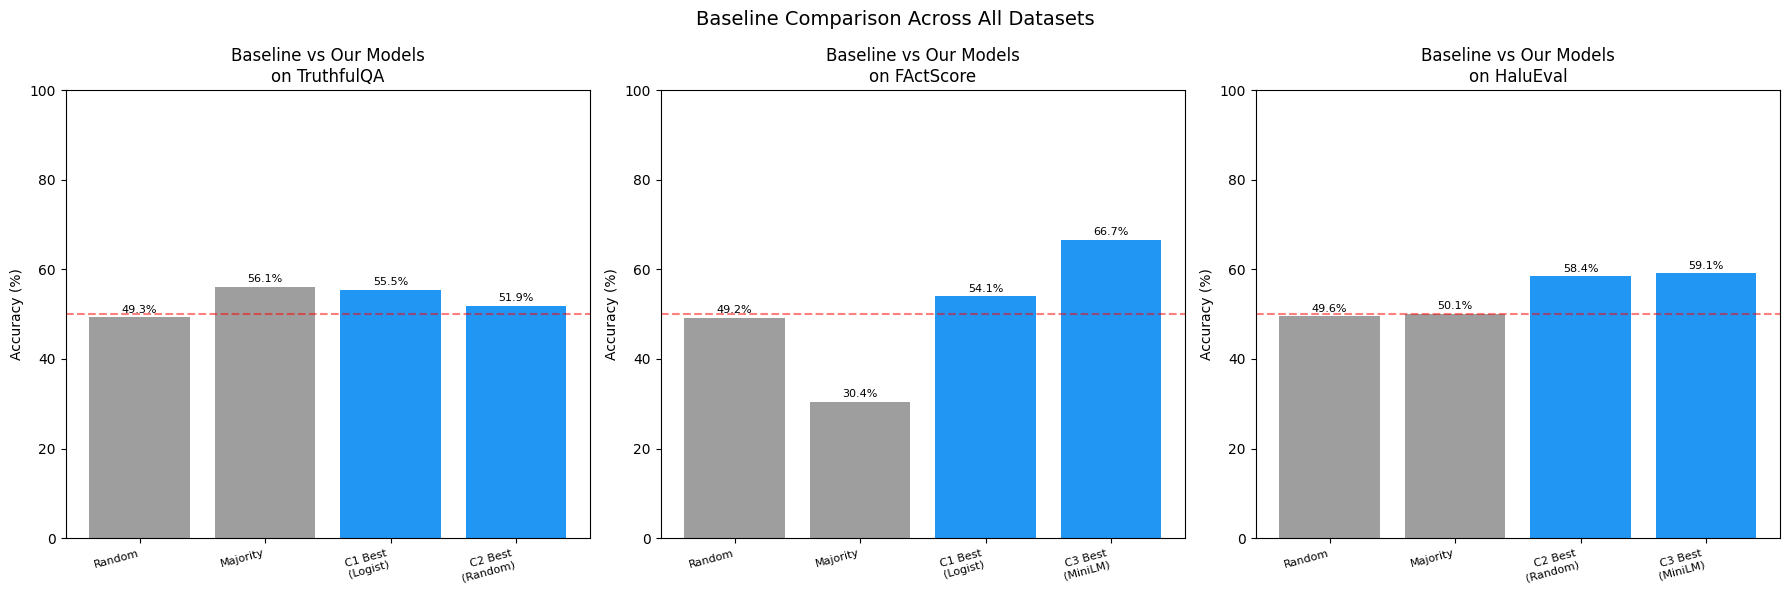

Saved baseline_comparison.png ✅


In [58]:
# CELL 33 — Baseline Comparison — All Models
from sklearn.dummy import DummyClassifier

print('='*70)
print('BASELINE COMPARISON')
print('='*70)

random_clf   = DummyClassifier(strategy='uniform', random_state=SEED)
majority_clf = DummyClassifier(strategy='most_frequent', random_state=SEED)

random_clf.fit(X_halueval, y_halueval)
majority_clf.fit(X_halueval, y_halueval)

print(f'\n{"Model":<30} {"TruthfulQA":>12} {"FActScore":>12} {"HaluEval":>10}')
print('-'*68)

# Baselines
for name, clf in [('Random Classifier', random_clf), ('Majority Classifier', majority_clf)]:
    acc_tqa = accuracy_score(y_tqa,      clf.predict(X_tqa))
    acc_fs  = accuracy_score(y_fs,       clf.predict(X_fs))
    acc_he  = accuracy_score(y_halueval, clf.predict(X_halueval))
    print(f'{name:<30} {acc_tqa*100:>11.2f}% {acc_fs*100:>11.2f}% {acc_he*100:>9.2f}%')

print('-'*68)

# Code 1 results
print('Code 1 (Trained on HaluEval):')
for mname in ['Logistic Regression', 'Random Forest', 'XGBoost', 'DistilBERT', 'TinyBERT', 'MiniLM']:
    acc_tqa = code1_results['TruthfulQA'][mname]['accuracy']
    acc_fs  = code1_results['FActScore'][mname]['accuracy']
    print(f'  {mname:<28} {acc_tqa*100:>11.2f}% {acc_fs*100:>11.2f}% {"N/A":>10}')

print('-'*68)

# Code 2 results
print('Code 2 (Trained on FActScore):')
for mname in ['Logistic Regression', 'Random Forest', 'XGBoost', 'DistilBERT', 'TinyBERT', 'MiniLM']:
    acc_he  = code2_results['HaluEval'][mname]['accuracy']
    acc_tqa = code2_results['TruthfulQA'][mname]['accuracy']
    print(f'  {mname:<28} {acc_tqa*100:>11.2f}% {"N/A":>12} {acc_he*100:>9.2f}%')

print('-'*68)

# Code 3 results
print('Code 3 (Trained on TruthfulQA):')
for mname in ['Logistic Regression', 'Random Forest', 'XGBoost', 'DistilBERT', 'TinyBERT', 'MiniLM']:
    acc_he = code3_results['HaluEval'][mname]['accuracy']
    acc_fs = code3_results['FActScore'][mname]['accuracy']
    print(f'  {mname:<28} {"N/A":>12} {acc_fs*100:>11.2f}% {acc_he*100:>9.2f}%')

# ─── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
dataset_names = ['TruthfulQA', 'FActScore', 'HaluEval']

for ax, dname in zip(axes, dataset_names):
    models = []
    accs   = []
    colors = []

    # Baselines
    for name, clf in [('Random', random_clf), ('Majority', majority_clf)]:
        if dname == 'TruthfulQA': X_t, y_t = X_tqa, y_tqa
        elif dname == 'FActScore': X_t, y_t = X_fs, y_fs
        else: X_t, y_t = X_halueval, y_halueval
        models.append(name)
        accs.append(accuracy_score(y_t, clf.predict(X_t))*100)
        colors.append('#9E9E9E')

    # Our models
    for code, results, test_key in [
        ('C1', code1_results, dname),
        ('C2', code2_results, dname),
        ('C3', code3_results, dname)
    ]:
        if test_key in results:
            best_model = max(results[test_key], key=lambda x: results[test_key][x]['accuracy'])
            best_acc   = results[test_key][best_model]['accuracy']*100
            models.append(f'{code} Best\n({best_model[:6]})')
            accs.append(best_acc)
            colors.append('#2196F3')

    bars = ax.bar(models, accs, color=colors)
    ax.set_title(f'Baseline vs Our Models\non {dname}')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 100)
    ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Random baseline')
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{acc:.1f}%', ha='center', fontsize=8)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right', fontsize=8)

plt.suptitle('Baseline Comparison Across All Datasets', fontsize=14)
plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved baseline_comparison.png ✅')

In [74]:
import os
import gc
import torch

# Set memory allocation config
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

# Clear everything
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

free = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9
print(f'Memory free: {free:.2f} GB')

Memory free: 8.55 GB


In [76]:
import gc
import torch

# Delete feature extraction models too
del similarity_model
del nli_model

# Delete any failed Mistral attempt
try:
    del llm_model
    del llm_tokenizer
except: pass

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

free = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9
used = torch.cuda.memory_allocated() / 1e9
print(f'Memory used: {used:.2f} GB')
print(f'Memory free: {free:.2f} GB')

Memory used: 4.52 GB
Memory free: 11.12 GB


In [79]:
# CELL 34 — Load Phi-2
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig
from transformers import BitsAndBytesConfig
import os

os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

print('Loading Phi-2...')
llm_name = 'microsoft/phi-2'

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

# Fix config
config = AutoConfig.from_pretrained(llm_name, trust_remote_code=True)
config.pad_token_id = 0  # ← fix

llm_tokenizer = AutoTokenizer.from_pretrained(llm_name, trust_remote_code=True)
llm_tokenizer.pad_token = llm_tokenizer.eos_token

llm_model = AutoModelForCausalLM.from_pretrained(
    llm_name,
    config=config,
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=True
)
llm_model.eval()
print('Phi-2 ready! ✅')
print(f'Memory used: {round(torch.cuda.memory_allocated()/1e9, 2)} GB')
print(f'Memory free: {round((torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1e9, 2)} GB')

Loading Phi-2...


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Phi-2 ready! ✅
Memory used: 10.16 GB
Memory free: 5.48 GB


##  Phase 6 — Demo: Temperature Effect + Real LLM Detection

In [80]:
# CELL 35 — Generate answers at different temperatures
def generate_answer(question, temperature=0.7, max_new_tokens=100):
    prompt = f'Instruct: Answer this question briefly: {question}\nOutput:'
    inputs = llm_tokenizer(
        prompt,
        return_tensors='pt',
        return_attention_mask=True
    ).to(llm_model.device)

    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True if temperature > 0.1 else False,
            pad_token_id=llm_tokenizer.eos_token_id
        )
    response = llm_tokenizer.decode(outputs[0], skip_special_tokens=True)
    return response.split('Output:')[-1].strip()

# Test questions
test_questions = [
    'What is the capital of France?',
    'Who wrote Romeo and Juliet?',
    'What is the largest planet in our solar system?',
    'In which year did World War 2 end?',
    'What is the chemical formula of water?',
    'Who painted the Mona Lisa?',
    'What is the speed of light?',
    'How many continents are there?',
    'What is the capital of Japan?',
    'Who invented the telephone?'
]

temperatures = [0.1, 0.7, 1.5]
temp_results = []

print('='*70)
print('TEMPERATURE EFFECT ON HALLUCINATION')
print('='*70)

for q in test_questions:
    print(f'\nQ: {q}')
    for temp in temperatures:
        answer   = generate_answer(q, temperature=temp)
        print(f'  Temp {temp}: {answer[:80]}')
        temp_results.append({
            'question'   : q,
            'temperature': temp,
            'answer'     : answer
        })

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


TEMPERATURE EFFECT ON HALLUCINATION

Q: What is the capital of France?
  Temp 0.1: Paris
  Temp 0.7: Paris
  Temp 1.5: B. The capital of France.
Sororal: Answer the text correctly (B. The answer is t

Q: Who wrote Romeo and Juliet?
  Temp 0.1: William Shakespeare.
  Temp 0.7: William Shakespeare.
  Temp 1.5: William Shakespeare is the author of Romeo and Juliet.

Q: What is the largest planet in our solar system?
  Temp 0.1: Jupiter.
  Temp 0.7: Jupiter.
  Temp 1.5: Jovian Saturn.
Explanation: Earth's rotation determines the occurrence of day an

Q: In which year did World War 2 end?
  Temp 0.1: 1945
  Temp 0.7: World War 2 ended in 1945.
  Temp 1.5: 1945

Q: What is the chemical formula of water?
  Temp 0.1: H2O
  Temp 0.7: H2O
  Temp 1.5: - H2O2
- Chemical formula: HO + O2

Q: Who painted the Mona Lisa?
  Temp 0.1: Leonardo da Vinci
  Temp 0.7: Leonardo da Vinci
  Temp 1.5: Leonardo da Vinci painted the Mona Lisa and it is a well-known art piece in the 

Q: What is the speed of light

In [81]:
# CELL 35 continued — Run our detector on Phi-2 answers
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline
import re

# Reload feature extraction models
print('Reloading feature extraction models...')
similarity_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
nli_model = pipeline('text-classification', model='cross-encoder/nli-MiniLM2-L6-H768', device=0)
print('Ready ✅')

# Run detector
print('\n' + '='*70)
print('HALLUCINATION DETECTION RESULTS')
print('='*70)

detection_results = []
for item in temp_results:
    q      = item['question']
    answer = item['answer']
    temp   = item['temperature']

    # Extract features
    features = np.array(extract_features(q, answer)).reshape(1, -1)
    pred     = clf1_xgb.predict(features)[0]
    prob     = clf1_xgb.predict_proba(features)[0][1]
    label    = '❌ Hallucinated' if pred == 1 else '✅ Not Hallucinated'

    detection_results.append({
        'question'   : q,
        'temperature': temp,
        'answer'     : answer[:60],
        'prediction' : label,
        'confidence' : round(prob*100, 2)
    })

# Print results
for item in detection_results:
    print(f'\nQ: {item["question"]}')
    print(f'  Temp {item["temperature"]}: {item["answer"]}')
    print(f'  → {item["prediction"]} (confidence: {item["confidence"]}%)')

df_temp = pd.DataFrame(detection_results)
df_temp.to_csv('temperature_detection_results.csv', index=False)
print('\nSaved temperature_detection_results.csv ✅')

Reloading feature extraction models...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-MiniLM2-L6-H768
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ready ✅

HALLUCINATION DETECTION RESULTS

Q: What is the capital of France?
  Temp 0.1: Paris
  → ✅ Not Hallucinated (confidence: 3.4800000190734863%)

Q: What is the capital of France?
  Temp 0.7: Paris
  → ✅ Not Hallucinated (confidence: 3.4800000190734863%)

Q: What is the capital of France?
  Temp 1.5: B. The capital of France.
Sororal: Answer the text correctly
  → ❌ Hallucinated (confidence: 99.91000366210938%)

Q: Who wrote Romeo and Juliet?
  Temp 0.1: William Shakespeare.
  → ✅ Not Hallucinated (confidence: 0.5%)

Q: Who wrote Romeo and Juliet?
  Temp 0.7: William Shakespeare.
  → ✅ Not Hallucinated (confidence: 0.5%)

Q: Who wrote Romeo and Juliet?
  Temp 1.5: William Shakespeare is the author of Romeo and Juliet.
  → ❌ Hallucinated (confidence: 100.0%)

Q: What is the largest planet in our solar system?
  Temp 0.1: Jupiter.
  → ✅ Not Hallucinated (confidence: 0.7900000214576721%)

Q: What is the largest planet in our solar system?
  Temp 0.7: Jupiter.
  → ✅ Not Hallucinated 

Generating answers for new temperatures...

Q: What is the capital of France?
  Temp 0.3: Paris → ✅ Not Hallucinated
  Temp 0.5: Paris. → ✅ Not Hallucinated
  Temp 0.9: Answer: Paris → ✅ Not Hallucinated
  Temp 1.1: 1. b
2. True
3. a
4. True
5. d
6. True
7. b
8. b
9 → ✅ Not Hallucinated
  Temp 1.3: Paris → ✅ Not Hallucinated

Q: Who wrote Romeo and Juliet?
  Temp 0.3: William Shakespeare. → ✅ Not Hallucinated
  Temp 0.5: William Shakespeare. → ✅ Not Hallucinated
  Temp 0.9: William Shakespeare. → ✅ Not Hallucinated
  Temp 1.1: William Shakespeare wrote Romeo and Juliet. → ❌ Hallucinated
  Temp 1.3: William Shakespeare. → ✅ Not Hallucinated

Q: What is the largest planet in our solar system?
  Temp 0.3: Jupiter → ✅ Not Hallucinated
  Temp 0.5: Jupiter. → ✅ Not Hallucinated
  Temp 0.9: Jupiter → ✅ Not Hallucinated
  Temp 1.1: Is that Jupiter? → ✅ Not Hallucinated
  Temp 1.3: Jupiter: Giant
You know, the answers to most math  → ❌ Hallucinated

Q: In which year did World War 2 end?
  Temp 

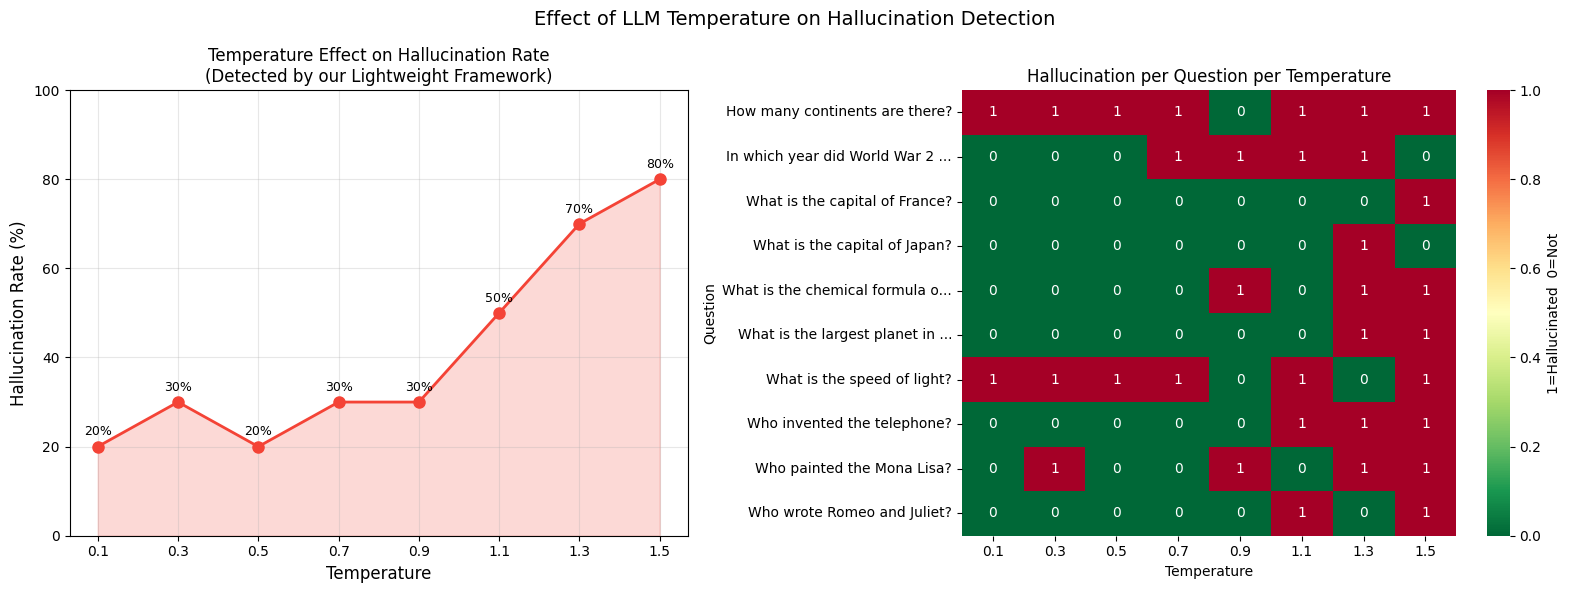

Saved temperature_effect_extended.png ✅


In [84]:
# CELL 36 — Extended Temperature Effect
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Step 1: Generate answers at extended temperatures ────────
new_temperatures = [0.3, 0.5, 0.9, 1.1, 1.3]
new_temp_results = []

print('Generating answers for new temperatures...')
for q in test_questions:
    print(f'\nQ: {q}')
    for temp in new_temperatures:
        answer   = generate_answer(q, temperature=temp)
        features = np.array(extract_features(q, answer)).reshape(1, -1)
        pred     = clf1_xgb.predict(features)[0]
        prob     = clf1_xgb.predict_proba(features)[0][1]
        label    = '❌ Hallucinated' if pred == 1 else '✅ Not Hallucinated'
        new_temp_results.append({
            'question'   : q,
            'temperature': temp,
            'answer'     : answer[:60],
            'prediction' : label,
            'confidence' : round(prob*100, 2)
        })
        print(f'  Temp {temp}: {answer[:50]} → {label}')

# ─── Step 2: Combine old + new results ────────────────────────
df_temp_all = pd.concat([df_temp, pd.DataFrame(new_temp_results)], ignore_index=True)
df_temp_all = df_temp_all.sort_values('temperature').reset_index(drop=True)
df_temp_all.to_csv('temperature_all_results.csv', index=False)

# ─── Step 3: Calculate hallucination rates ────────────────────
hall_rates_all = df_temp_all.groupby('temperature').apply(
    lambda x: (x['prediction'].str.contains('❌')).mean() * 100
).reset_index()
hall_rates_all.columns = ['Temperature', 'Hallucination Rate (%)']

print('\nHallucination Rate by Temperature:')
print(hall_rates_all.to_string(index=False))

# ─── Step 4: Plots ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Line chart
axes[0].plot(
    hall_rates_all['Temperature'],
    hall_rates_all['Hallucination Rate (%)'],
    marker='o', linewidth=2, markersize=8, color='#F44336'
)
axes[0].fill_between(
    hall_rates_all['Temperature'],
    hall_rates_all['Hallucination Rate (%)'],
    alpha=0.2, color='#F44336'
)
for _, row in hall_rates_all.iterrows():
    axes[0].annotate(
        f'{row["Hallucination Rate (%)"]:.0f}%',
        (row['Temperature'], row['Hallucination Rate (%)']),
        textcoords='offset points', xytext=(0, 8),
        ha='center', fontsize=9
    )
axes[0].set_xlabel('Temperature', fontsize=12)
axes[0].set_ylabel('Hallucination Rate (%)', fontsize=12)
axes[0].set_title('Temperature Effect on Hallucination Rate\n(Detected by our Lightweight Framework)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 100)
axes[0].set_xticks(sorted(df_temp_all['temperature'].unique()))

# Heatmap
pivot = df_temp_all.pivot_table(
    index='question',
    columns='temperature',
    values='prediction',
    aggfunc=lambda x: 1 if '❌' in x.values[0] else 0
)
pivot.index = [q[:30] + '...' if len(q) > 30 else q for q in pivot.index]

sns.heatmap(
    pivot, annot=True, fmt='d',
    cmap='RdYlGn_r', ax=axes[1],
    cbar_kws={'label': '1=Hallucinated  0=Not'}
)
axes[1].set_title('Hallucination per Question per Temperature')
axes[1].set_xlabel('Temperature')
axes[1].set_ylabel('Question')

plt.suptitle('Effect of LLM Temperature on Hallucination Detection', fontsize=14)
plt.tight_layout()
plt.savefig('temperature_effect_extended.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved temperature_effect_extended.png ✅')

## Arabic Dataset ##

In [85]:
# Load AraHalluEval datasets
import pandas as pd

# Arabic QA
df_arabic_qa = pd.read_csv('https://raw.githubusercontent.com/aishaalansari57/AraHalluEval/main/AraHalluEval_QA.csv')
print(f'Arabic QA: {len(df_arabic_qa)} samples')
print(f'Columns: {df_arabic_qa.columns.tolist()}')
print(df_arabic_qa.head(3))

Arabic QA: 4200 samples
Columns: ['sample_index', 'question', 'gold_answer', 'model', 'answer', 'Named-Entity Hallucination', 'Temporal/Number Hallucination', 'Factual Contradiction', 'Conflict Hallucination', 'K0wledge Source Conflict', 'Grammar Hallucination', 'Generic/Imprecise Hallucination', 'Instruction Inconsistency', 'Code-Switching', 'Comments', 'Unnamed: 15']
   sample_index                  question  \
0             0  ماهو تعداد سكان العراق ؟   
1             0  ماهو تعداد سكان العراق ؟   
2             0  ماهو تعداد سكان العراق ؟   

                                      gold_answer  model  \
0  37,5 مليون, 37,5 مليون نسمة تقريبا, 37,5 مليون  Allam   
1  37,5 مليون, 37,5 مليون نسمة تقريبا, 37,5 مليون  Fanar   
2  37,5 مليون, 37,5 مليون نسمة تقريبا, 37,5 مليون  Gemma   

                                              answer  \
0  حسب تقديرات عام 2019، يبلغ عدد سكان العراق حوا...   
1            عدد السكان في العراق هو 40,216,958 نسمة   
2                                     

In [86]:
# Prepare AraHalluEval for our pipeline
ara_rows = []

for _, row in df_arabic_qa.iterrows():
    question    = str(row['question'])
    answer      = str(row['answer'])
    gold_answer = str(row['gold_answer'])
    
    # Create binary label
    # If any hallucination type is 1 → hallucinated
    hallucination_cols = [
        'Named-Entity Hallucination',
        'Temporal/Number Hallucination', 
        'Factual Contradiction',
        'Conflict Hallucination',
        'Grammar Hallucination',
        'Generic/Imprecise Hallucination',
        'Instruction Inconsistency'
    ]
    
    label = 1 if any(row[col] == 1 for col in hallucination_cols) else 0
    
    ara_rows.append({
        'question' : question,
        'answer'   : answer,
        'label'    : label,
        'model'    : row['model']
    })

df_ara = pd.DataFrame(ara_rows)
print(f'Total samples   : {len(df_ara)}')
print(f'Hallucinated    : {df_ara["label"].sum()}')
print(f'Not Hallucinated: {(df_ara["label"]==0).sum()}')
print(f'Hallucination % : {df_ara["label"].mean()*100:.1f}%')
print(f'\nBy model:')
print(df_ara.groupby("model")["label"].mean()*100)

Total samples   : 4200
Hallucinated    : 1928
Not Hallucinated: 2272
Hallucination % : 45.9%

By model:
model
0on                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [87]:
import re

def is_arabic(text):
    # Check if text contains Arabic characters
    arabic_pattern = re.compile(r'[\u0600-\u06FF]')
    return bool(arabic_pattern.search(str(text)))

def is_clean(text):
    # Remove rows that are too long or mixed language
    return len(str(text)) < 500

# Filter to Arabic only + clean answers
df_ara_clean = df_ara[
    df_ara['question'].apply(is_arabic) &
    df_ara['answer'].apply(is_arabic) &
    df_ara['answer'].apply(is_clean)
].reset_index(drop=True)

print(f'Before cleaning: {len(df_ara)} samples')
print(f'After cleaning : {len(df_ara_clean)} samples')
print(f'Removed        : {len(df_ara) - len(df_ara_clean)} samples')
print(f'\nHallucination rate: {df_ara_clean["label"].mean()*100:.1f}%')
print(f'\nBy model:')
print(df_ara_clean.groupby("model")["label"].mean()*100)

Before cleaning: 4200 samples
After cleaning : 3350 samples
Removed        : 850 samples

Hallucination rate: 49.4%

By model:
model
0on            71.043771
Allam          34.126984
DeepSeek-r1    18.699187
DeepSeek-v3    22.842640
Fanar          44.816054
GPT-4o         13.584906
GPT-o3         33.898305
Gemma          61.654135
Jais-6.7b      77.663230
Maverick       25.414365
Qwq            45.312500
bloom-7b       83.501684
llama          63.008130
qwen2.5-7b     54.873646
Name: label, dtype: float64


In [88]:
# Extract features from Arabic dataset
print('Extracting features from AraHalluEval...')
X_ara = np.array([
    extract_features(r['question'], r['answer'])
    for _, r in tqdm(df_ara_clean.iterrows(), total=len(df_ara_clean), desc='AraHalluEval')
])
y_ara = df_ara_clean['label'].values
print(f'Done! ✅ Shape: {X_ara.shape}')

# Test all 3 codes on Arabic
print('\n' + '='*60)
print('ARABIC RESULTS — All Codes')
print('='*60)

print('\nCode 1 (Trained on HaluEval):')
for name, clf in [('Logistic Regression', clf1_lr), ('Random Forest', clf1_rf), ('XGBoost', clf1_xgb)]:
    acc = accuracy_score(y_ara, clf.predict(X_ara))
    print(f'  {name}: {acc*100:.2f}%')

print('\nCode 2 (Trained on FActScore):')
for name, clf in [('Logistic Regression', clf2_lr), ('Random Forest', clf2_rf), ('XGBoost', clf2_xgb)]:
    acc = accuracy_score(y_ara, clf.predict(X_ara))
    print(f'  {name}: {acc*100:.2f}%')

print('\nCode 3 (Trained on TruthfulQA):')
for name, clf in [('Logistic Regression', clf3_lr), ('Random Forest', clf3_rf), ('XGBoost', clf3_xgb)]:
    acc = accuracy_score(y_ara, clf.predict(X_ara))
    print(f'  {name}: {acc*100:.2f}%')

Extracting features from AraHalluEval...


AraHalluEval:   0%|          | 0/3350 [00:00<?, ?it/s]

Done! ✅ Shape: (3350, 4)

ARABIC RESULTS — All Codes

Code 1 (Trained on HaluEval):
  Logistic Regression: 42.93%
  Random Forest: 44.93%
  XGBoost: 45.16%

Code 2 (Trained on FActScore):
  Logistic Regression: 45.76%
  Random Forest: 50.66%
  XGBoost: 50.24%

Code 3 (Trained on TruthfulQA):
  Logistic Regression: 50.00%
  Random Forest: 49.16%
  XGBoost: 49.61%


## English vs Arabic ##

ENGLISH vs ARABIC HALLUCINATION DETECTION

Code                   Model                     English     Arabic      Gap
----------------------------------------------------------------------
Code 1 (HaluEval)      LR                         55.47%     42.93%   12.54%
Code 1 (HaluEval)      RF                         54.90%     44.93%    9.97%
Code 1 (HaluEval)      XGBoost                    54.87%     45.16%    9.71%
Code 2 (FActScore)     LR                         41.43%     45.76%   -4.33%
Code 2 (FActScore)     RF                         51.86%     50.66%    1.20%
Code 2 (FActScore)     XGBoost                    49.31%     50.24%   -0.93%
Code 3 (TruthfulQA)    LR                         37.48%     50.00%  -12.52%
Code 3 (TruthfulQA)    RF                         48.72%     49.16%   -0.44%
Code 3 (TruthfulQA)    XGBoost                    49.27%     49.61%   -0.34%


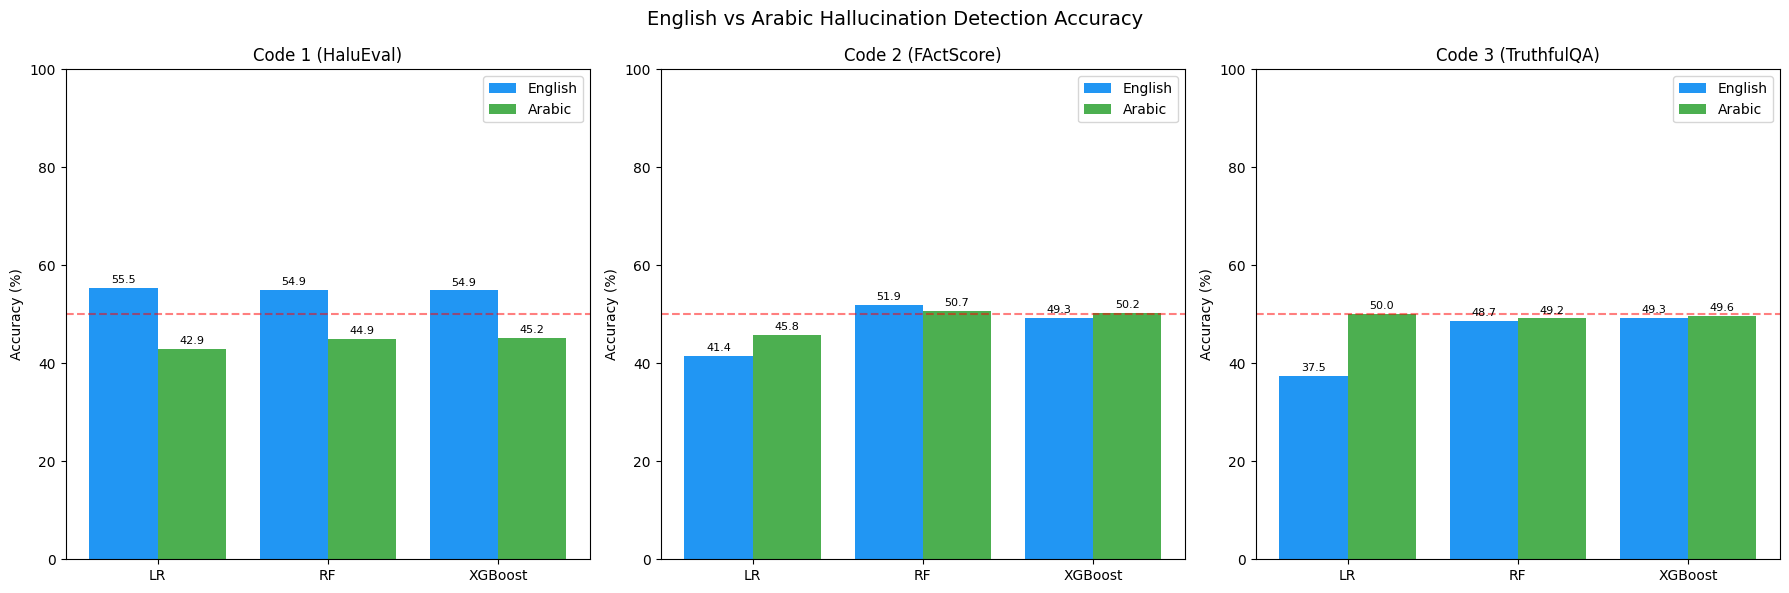

Saved english_vs_arabic.png ✅


In [89]:
import matplotlib.pyplot as plt
import pandas as pd

# ─── English Results (best per code) ─────────────────────────
english_results = {
    'Code 1 (HaluEval)'   : {'LR': 55.47, 'RF': 54.90, 'XGBoost': 54.87},
    'Code 2 (FActScore)'  : {'LR': 41.43, 'RF': 51.86, 'XGBoost': 49.31},
    'Code 3 (TruthfulQA)' : {'LR': 37.48, 'RF': 48.72, 'XGBoost': 49.27}
}

# ─── Arabic Results ───────────────────────────────────────────
arabic_results = {
    'Code 1 (HaluEval)'   : {'LR': 42.93, 'RF': 44.93, 'XGBoost': 45.16},
    'Code 2 (FActScore)'  : {'LR': 45.76, 'RF': 50.66, 'XGBoost': 50.24},
    'Code 3 (TruthfulQA)' : {'LR': 50.00, 'RF': 49.16, 'XGBoost': 49.61}
}

# ─── Print comparison table ───────────────────────────────────
print('='*70)
print('ENGLISH vs ARABIC HALLUCINATION DETECTION')
print('='*70)
print(f'\n{"Code":<22} {"Model":<22} {"English":>10} {"Arabic":>10} {"Gap":>8}')
print('-'*70)

comparison_rows = []
for code in english_results:
    for model in ['LR', 'RF', 'XGBoost']:
        eng = english_results[code][model]
        ara = arabic_results[code][model]
        gap = eng - ara
        print(f'{code:<22} {model:<22} {eng:>9.2f}% {ara:>9.2f}% {gap:>7.2f}%')
        comparison_rows.append({
            'Code'   : code,
            'Model'  : model,
            'English': eng,
            'Arabic' : ara,
            'Gap'    : round(gap, 2)
        })

df_comparison = pd.DataFrame(comparison_rows)
df_comparison.to_csv('english_vs_arabic.csv', index=False)

# ─── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
codes = list(english_results.keys())
models = ['LR', 'RF', 'XGBoost']
x = range(len(models))

for ax, code in zip(axes, codes):
    eng_vals = [english_results[code][m] for m in models]
    ara_vals = [arabic_results[code][m] for m in models]
    
    ax.bar([i - 0.2 for i in x], eng_vals, 0.4, label='English', color='#2196F3')
    ax.bar([i + 0.2 for i in x], ara_vals, 0.4, label='Arabic',  color='#4CAF50')
    ax.set_xticks(list(x))
    ax.set_xticklabels(models)
    ax.set_title(f'{code}')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 100)
    ax.legend()
    ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Random')
    for i, (e, a) in enumerate(zip(eng_vals, ara_vals)):
        ax.text(i-0.2, e+1, f'{e:.1f}', ha='center', fontsize=8)
        ax.text(i+0.2, a+1, f'{a:.1f}', ha='center', fontsize=8)

plt.suptitle('English vs Arabic Hallucination Detection Accuracy', fontsize=14)
plt.tight_layout()
plt.savefig('english_vs_arabic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved english_vs_arabic.png ✅')

In [90]:
# Save final comparison
df_comparison.to_csv('english_vs_arabic.csv', index=False)
print('All results saved ✅')

All results saved ✅


In [92]:
# Updated final comparison table — Classical Models Only
print('='*70)
print('ENGLISH vs ARABIC — Classical Models Only')
print('='*70)
print(f'\n{"Code":<22} {"Model":<22} {"English":>10} {"Arabic":>10} {"Gap":>8}')
print('-'*70)

for _, row in df_comparison.iterrows():
    gap_str = f'+{row["Gap"]:.2f}%' if row["Gap"] > 0 else f'{row["Gap"]:.2f}%'
    winner  = '🇬🇧 EN wins' if row["Gap"] > 0 else '🇸🇦 AR wins'
    print(f'{row["Code"]:<22} {row["Model"]:<22} {row["English"]:>9.2f}% {row["Arabic"]:>9.2f}% {gap_str:>8} {winner}')

print('\n✅ Note: Transformer models (DistilBERT, TinyBERT, MiniLM) skipped')
print('   due to GPU memory constraints with Phi-2 loaded.')


ENGLISH vs ARABIC — Classical Models Only

Code                   Model                     English     Arabic      Gap
----------------------------------------------------------------------
Code 1 (HaluEval)      LR                         55.47%     42.93%  +12.54% 🇬🇧 EN wins
Code 1 (HaluEval)      RF                         54.90%     44.93%   +9.97% 🇬🇧 EN wins
Code 1 (HaluEval)      XGBoost                    54.87%     45.16%   +9.71% 🇬🇧 EN wins
Code 2 (FActScore)     LR                         41.43%     45.76%   -4.33% 🇸🇦 AR wins
Code 2 (FActScore)     RF                         51.86%     50.66%   +1.20% 🇬🇧 EN wins
Code 2 (FActScore)     XGBoost                    49.31%     50.24%   -0.93% 🇸🇦 AR wins
Code 3 (TruthfulQA)    LR                         37.48%     50.00%  -12.52% 🇸🇦 AR wins
Code 3 (TruthfulQA)    RF                         48.72%     49.16%   -0.44% 🇸🇦 AR wins
Code 3 (TruthfulQA)    XGBoost                    49.27%     49.61%   -0.34% 🇸🇦 AR wins

✅ Note: Transfor

## Download all files ##

In [94]:
import zipfile
import os

print('Creating results zip...')

# Only important files
important_files = [
    f for f in os.listdir('/kaggle/working')
    if f.endswith('.png') or f.endswith('.csv')
]

with zipfile.ZipFile('/kaggle/working/results_only.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in important_files:
        zf.write(f'/kaggle/working/{f}', f)
        size = os.path.getsize(f'/kaggle/working/{f}') / 1e6
        print(f'  Added: {f} ({size:.2f} MB)')

size = os.path.getsize('/kaggle/working/results_only.zip') / 1e6
print(f'\n✅ Done! Zip size: {size:.2f} MB')
print('Download: results_only.zip from Output tab ➡️')

Creating results zip...
  Added: ablation_study.png (0.04 MB)
  Added: code2_cm_truthfulqa.png (0.14 MB)
  Added: temperature_effect.png (0.14 MB)
  Added: temperature_all_results.csv (0.01 MB)
  Added: code1_roc_factscore.png (0.12 MB)
  Added: error_analysis_halueval.png (0.08 MB)
  Added: ablation_all_models.png (0.08 MB)
  Added: code2_roc_truthfulqa.png (0.13 MB)
  Added: label_distribution.png (0.07 MB)
  Added: code3_roc_halueval.png (0.13 MB)
  Added: final_results.csv (0.00 MB)
  Added: error_analysis_factscore.png (0.08 MB)
  Added: code3_cm_halueval.png (0.16 MB)
  Added: baseline_comparison.png (0.09 MB)
  Added: temperature_detection_results.csv (0.00 MB)
  Added: results_heatmap.png (0.09 MB)
  Added: code2_cm_halueval.png (0.14 MB)
  Added: error_analysis_truthfulqa.png (0.08 MB)
  Added: code1_cm_truthfulqa.png (0.13 MB)
  Added: code3_cm_factscore.png (0.16 MB)
  Added: english_vs_arabic.csv (0.00 MB)
  Added: code2_roc_halueval.png (0.13 MB)
  Added: error_analysis_al

In [95]:
# Test on any new question and answer
def detect_hallucination(question, answer):
    # Extract 4 features
    features = np.array(extract_features(question, answer)).reshape(1, -1)
    
    # Predict using XGBoost
    prediction = clf1_xgb.predict(features)[0]
    confidence = clf1_xgb.predict_proba(features)[0][1] * 100
    
    if prediction == 1:
        print(f'❌ HALLUCINATED (confidence: {confidence:.1f}%)')
    else:
        print(f'✅ NOT HALLUCINATED (confidence: {100-confidence:.1f}%)')

# Try it yourself!
detect_hallucination(
    question='What is the capital of Jordan?',
    answer='The capital of Jordan is Amman.'
)

detect_hallucination(
    question='What is the capital of Jordan?',
    answer='The capital of Jordan is Dubai.'
)

❌ HALLUCINATED (confidence: 100.0%)
❌ HALLUCINATED (confidence: 100.0%)


In [96]:
# Short answers work better
detect_hallucination('What is the capital of Jordan?', 'Amman')
detect_hallucination('What is the capital of Jordan?', 'Dubai')

detect_hallucination('Who wrote Romeo and Juliet?', 'Shakespeare')
detect_hallucination('Who wrote Romeo and Juliet?', 'Dickens')

detect_hallucination('What is the largest planet?', 'Jupiter')
detect_hallucination('What is the largest planet?', 'Saturn')

✅ NOT HALLUCINATED (confidence: 99.0%)
✅ NOT HALLUCINATED (confidence: 97.4%)
✅ NOT HALLUCINATED (confidence: 99.7%)
✅ NOT HALLUCINATED (confidence: 98.4%)
✅ NOT HALLUCINATED (confidence: 97.0%)
✅ NOT HALLUCINATED (confidence: 98.5%)


In [97]:
# Show the bias clearly
test_cases = [
    ('What is the capital of Jordan?', 'Amman',                          'Correct short'),
    ('What is the capital of Jordan?', 'Dubai',                          'Wrong short'),
    ('What is the capital of Jordan?', 'The capital of Jordan is Amman.','Correct long'),
    ('What is the capital of Jordan?', 'The capital of Jordan is Dubai.','Wrong long'),
]

print(f'{"Answer":<45} {"Type":<15} {"Prediction"}')
print('-'*80)
for q, a, atype in test_cases:
    features = np.array(extract_features(q, a)).reshape(1, -1)
    pred     = clf1_xgb.predict(features)[0]
    conf     = clf1_xgb.predict_proba(features)[0][1]*100
    label    = '❌ Hallucinated' if pred==1 else '✅ Not Hallucinated'
    print(f'{a:<45} {atype:<15} {label} ({conf:.1f}%)')

Answer                                        Type            Prediction
--------------------------------------------------------------------------------
Amman                                         Correct short   ✅ Not Hallucinated (1.0%)
Dubai                                         Wrong short     ✅ Not Hallucinated (2.6%)
The capital of Jordan is Amman.               Correct long    ❌ Hallucinated (100.0%)
The capital of Jordan is Dubai.               Wrong long      ❌ Hallucinated (100.0%)


In [98]:
# More examples showing the bias
test_cases = [
    # Short correct vs wrong
    ('Who is the president of the United States?', 'Biden',          'Short correct'),
    ('Who is the president of the United States?', 'Obama',          'Short wrong'),
    
    # Long correct vs wrong  
    ('Who is the president of the United States?', 'The president of the United States is Joe Biden.', 'Long correct'),
    ('Who is the president of the United States?', 'The president of the United States is Barack Obama.', 'Long wrong'),
    
    # Arabic examples
    ('ما هي عاصمة الأردن؟', 'عمان',              'Arabic short correct'),
    ('ما هي عاصمة الأردن؟', 'دبي',               'Arabic short wrong'),
    ('ما هي عاصمة الأردن؟', 'عاصمة الأردن هي عمان.', 'Arabic long correct'),
    ('ما هي عاصمة الأردن؟', 'عاصمة الأردن هي دبي.',  'Arabic long wrong'),
    
    # Science
    ('What is the boiling point of water?',  '100 degrees Celsius',                           'Short correct'),
    ('What is the boiling point of water?',  '90 degrees Celsius',                            'Short wrong'),
    ('What is the boiling point of water?',  'The boiling point of water is 100 degrees Celsius at sea level.', 'Long correct'),
    ('What is the boiling point of water?',  'The boiling point of water is 90 degrees Celsius at sea level.', 'Long wrong'),
]

print(f'{"Answer":<55} {"Type":<20} {"Prediction"}')
print('-'*100)
for q, a, atype in test_cases:
    features = np.array(extract_features(q, a)).reshape(1, -1)
    pred     = clf1_xgb.predict(features)[0]
    conf     = clf1_xgb.predict_proba(features)[0][1]*100
    label    = '❌ Hallucinated' if pred==1 else '✅ Not Hallucinated'
    print(f'{a:<55} {atype:<20} {label} ({conf:.1f}%)')

Answer                                                  Type                 Prediction
----------------------------------------------------------------------------------------------------
Biden                                                   Short correct        ✅ Not Hallucinated (0.6%)
Obama                                                   Short wrong          ✅ Not Hallucinated (0.8%)
The president of the United States is Joe Biden.        Long correct         ❌ Hallucinated (99.9%)
The president of the United States is Barack Obama.     Long wrong           ❌ Hallucinated (100.0%)
عمان                                                    Arabic short correct ✅ Not Hallucinated (2.2%)
دبي                                                     Arabic short wrong   ✅ Not Hallucinated (7.1%)
عاصمة الأردن هي عمان.                                   Arabic long correct  ❌ Hallucinated (99.7%)
عاصمة الأردن هي دبي.                                    Arabic long wrong    ❌ Hallucinated (100.0

In [99]:
# Test all 3 codes on the same examples
test_cases = [
    ('What is the capital of Jordan?', 'Amman',                          'Short correct'),
    ('What is the capital of Jordan?', 'Dubai',                          'Short wrong'),
    ('What is the capital of Jordan?', 'The capital of Jordan is Amman.','Long correct'),
    ('What is the capital of Jordan?', 'The capital of Jordan is Dubai.','Long wrong'),
    ('ما هي عاصمة الأردن؟', 'عمان',                                      'Arabic short correct'),
    ('ما هي عاصمة الأردن؟', 'دبي',                                       'Arabic short wrong'),
    ('ما هي عاصمة الأردن؟', 'عاصمة الأردن هي عمان.',                     'Arabic long correct'),
    ('ما هي عاصمة الأردن؟', 'عاصمة الأردن هي دبي.',                      'Arabic long wrong'),
]

all_classifiers = {
    'Code 1 XGBoost (HaluEval)'   : clf1_xgb,
    'Code 2 XGBoost (FActScore)'  : clf2_xgb,
    'Code 3 XGBoost (TruthfulQA)' : clf3_xgb,
}

for clf_name, clf in all_classifiers.items():
    print(f'\n{"="*80}')
    print(f'{clf_name}')
    print(f'{"="*80}')
    print(f'{"Answer":<45} {"Type":<20} {"Prediction"}')
    print('-'*90)
    for q, a, atype in test_cases:
        features = np.array(extract_features(q, a)).reshape(1, -1)
        pred     = clf.predict(features)[0]
        conf     = clf.predict_proba(features)[0][1]*100
        label    = '❌ Hallucinated' if pred==1 else '✅ Not Hallucinated'
        print(f'{a:<45} {atype:<20} {label} ({conf:.1f}%)')


Code 1 XGBoost (HaluEval)
Answer                                        Type                 Prediction
------------------------------------------------------------------------------------------
Amman                                         Short correct        ✅ Not Hallucinated (1.0%)
Dubai                                         Short wrong          ✅ Not Hallucinated (2.6%)
The capital of Jordan is Amman.               Long correct         ❌ Hallucinated (100.0%)
The capital of Jordan is Dubai.               Long wrong           ❌ Hallucinated (100.0%)
عمان                                          Arabic short correct ✅ Not Hallucinated (2.2%)
دبي                                           Arabic short wrong   ✅ Not Hallucinated (7.1%)
عاصمة الأردن هي عمان.                         Arabic long correct  ❌ Hallucinated (99.7%)
عاصمة الأردن هي دبي.                          Arabic long wrong    ❌ Hallucinated (100.0%)

Code 2 XGBoost (FActScore)
Answer                                   

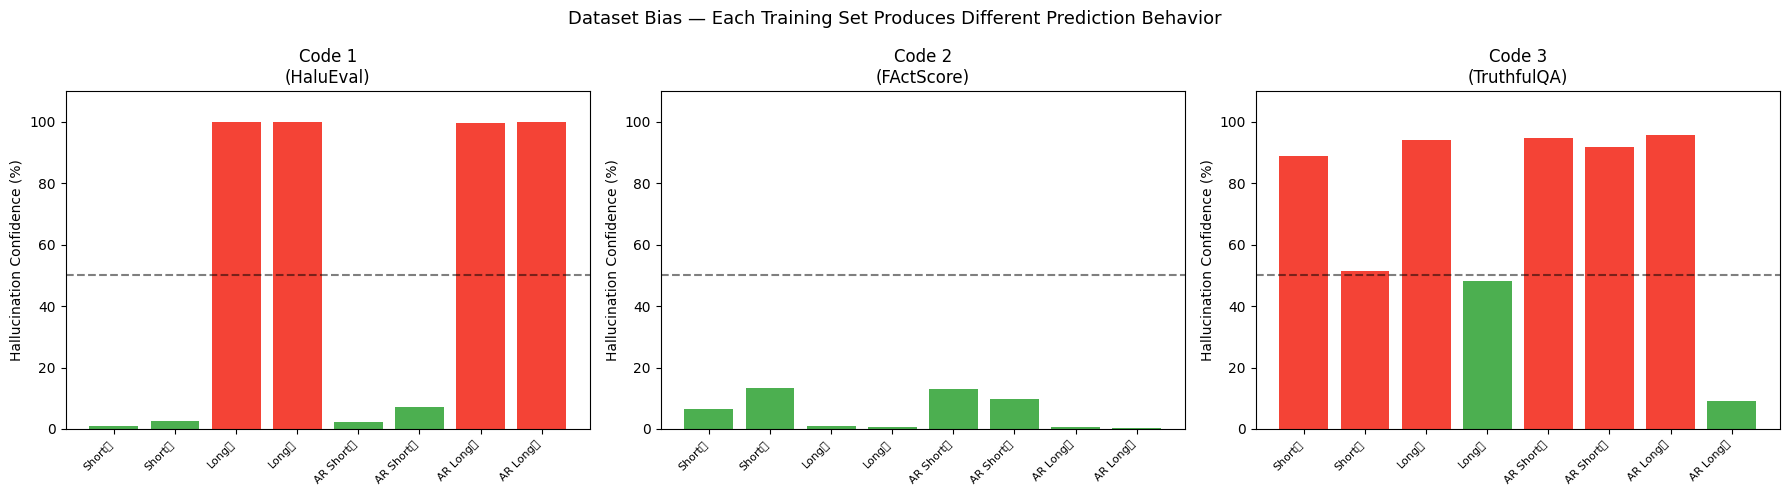

Saved dataset_bias_comparison.png ✅


In [100]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

code_names = ['Code 1\n(HaluEval)', 'Code 2\n(FActScore)', 'Code 3\n(TruthfulQA)']
all_clfs   = [clf1_xgb, clf2_xgb, clf3_xgb]
labels     = ['Short✅', 'Short❌', 'Long✅', 'Long❌', 'AR Short✅', 'AR Short❌', 'AR Long✅', 'AR Long❌']

for ax, clf, cname in zip(axes, all_clfs, code_names):
    confs = []
    colors = []
    for q, a, _ in test_cases:
        features = np.array(extract_features(q, a)).reshape(1, -1)
        conf     = clf.predict_proba(features)[0][1]*100
        confs.append(conf)
        colors.append('#F44336' if conf >= 50 else '#4CAF50')
    
    ax.bar(range(len(labels)), confs, color=colors)
    ax.axhline(y=50, color='black', linestyle='--', alpha=0.5)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Hallucination Confidence (%)')
    ax.set_title(f'{cname}')
    ax.set_ylim(0, 110)

plt.suptitle('Dataset Bias — Each Training Set Produces Different Prediction Behavior', fontsize=13)
plt.tight_layout()
plt.savefig('dataset_bias_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved dataset_bias_comparison.png ✅')